In [1]:
# Import packages for data manipulation
# Import relevant libraries and modules.

import numpy as np
import pandas as pd



# This is the function that helps plot feature importance 
from xgboost import plot_importance

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

import matplotlib.pyplot as plt

# This displays all of the columns, preventing Juptyer from redacting them.
pd.set_option('display.max_columns', None)

# This module lets us save our models once we fit them.
import pickle

# This lets us see all of the columns, preventing Juptyer from redacting them.
pd.set_option('display.max_columns', None)


# This is the function that helps plot feature importance
from xgboost import plot_importance

# # This module lets us save our models once we fit them.
import pickle

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/oladayofolasire/remodeled-mh-2016/mental_heath_in_tech_2016.csv


In [2]:
# Read in data
file = '/kaggle/input/datasets/oladayofolasire/remodeled-mh-2016/mental_heath_in_tech_2016.csv'
df = pd.read_csv(file)
df.head(10)

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Do you feel that your employer takes mental health as seriously as physical health?,Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,Do you know local or online resources to seek help for a mental health disorder?,"If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?","If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?","If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?","If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?",Do you believe your productivity is ever affected by a mental health issue?,"If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?",Do you have previous employers?,Have your previous employers provided mental health benefits?,Were you aware of the options for mental health care provided by your previous employers?,Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?,Did your previous employers provide resources to learn more about mental health issues and how to seek help?,Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Do you think that discussing a physical health issue with previous employers would have negative consequences?,Would you have been willing to discuss a mental health issue with your previous co-workers?,Would you have been willing to discuss a mental health issue with your direct supervisor(s)?,Did you feel that your previous employers took mental health as seriously as physical health?,Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?,Would you be willing to bring up a physical health issue with a potential employer in an interview?,Why or why not?,Would you bring up a mental health issue with a potential employer in an interview?,Why or why not?.1,Do you feel that being identified as a person with a mental health issue would hurt your career?,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a menta

In [3]:
df.describe()

,Are you self-employed?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,Do you have previous employers?,Have you ever sought treatment for a mental health issue from a mental health professional?,What is your age?
count,1433.000000,1146.000000,263.000000,287.000000,1433.000000,1433.000000,1433.000000
mean,0.200279,0.770506,0.942966,0.644599,0.882066,0.585485,34.286113
std,0.400349,0.420691,0.232350,0.479471,0.322643,0.492810,11.290931
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
25%,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,28.000000
50%,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,33.000000
75%,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,39.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,323.000000


In [4]:
df.columns

Index(['Are you self-employed?',
       'How many employees does your company or organization have?',
       'Is your employer primarily a tech company/organization?',
       'Is your primary role within your company related to tech/IT?',
       'Does your employer provide mental health benefits as part of healthcare coverage?',
       'Do you know the options for mental health care available under your employer-provided coverage?',
       'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?',
       'Does your employer offer resources to learn more about mental health concerns and options for seeking help?',
       'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?',
       'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:',
       'Do you think that dis

In [5]:
# Column names as a list
print(df.columns.tolist())

['Are you self-employed?', 'How many employees does your company or organization have?', 'Is your employer primarily a tech company/organization?', 'Is your primary role within your company related to tech/IT?', 'Does your employer provide mental health benefits as part of healthcare coverage?', 'Do you know the options for mental health care available under your employer-provided coverage?', 'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?', 'Does your employer offer resources to learn more about mental health concerns and options for seeking help?', 'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?', 'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:', 'Do you think that discussing a mental health disorder with your employer would have negative cons

In [6]:
# Rename long survey columns to short ML-friendly names

df = df.rename(columns={
    'Are you self-employed?': 'self_employed',
    'How many employees does your company or organization have?': 'company_size',
    'Is your employer primarily a tech company/organization?': 'employer_tech',
    'Is your primary role within your company related to tech/IT?': 'role_tech',
    'Does your employer provide mental health benefits as part of healthcare coverage?': 'mh_benefits',
    'Do you know the options for mental health care available under your employer-provided coverage?': 'mh_coverage_awareness',
    'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?': 'employer_mh_discussion',
    'Does your employer offer resources to learn more about mental health concerns and options for seeking help?': 'mh_resources',
    'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?': 'mh_anonymity_protected',
    'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:': 'mh_leave_ease',
    'Do you think that discussing a mental health disorder with your employer would have negative consequences?': 'mh_disclose_employer_negative',
    'Do you think that discussing a physical health issue with your employer would have negative consequences?': 'ph_disclose_employer_negative',
    'Would you feel comfortable discussing a mental health disorder with your coworkers?': 'mh_comfort_coworkers',
    'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?': 'mh_comfort_supervisor',
    'Do you feel that your employer takes mental health as seriously as physical health?': 'mh_equal_ph_employer',
    'Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?': 'mh_negative_consequences_workplace',
    'Do you have medical coverage (private insurance or state-provided) which includes treatment of \xa0mental health issues?': 'mh_medical_coverage',
    'Do you know local or online resources to seek help for a mental health disorder?': 'mh_help_resources_known',
    'If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?': 'mh_reveal_clients',
    'If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?': 'mh_reveal_clients_negative',
    'If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?': 'mh_reveal_coworkers',
    'If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?': 'mh_reveal_coworkers_negative',
    'Do you believe your productivity is ever affected by a mental health issue?': 'mh_productivity_affected',
    'If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?': 'mh_work_time_affected_pct',
    'Do you have previous employers?': 'previous_employers',
    'Have your previous employers provided mental health benefits?': 'prev_mh_benefits',
    'Were you aware of the options for mental health care provided by your previous employers?': 'prev_mh_coverage_awareness',
    'Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?': 'prev_employer_mh_discussion',
    'Did your previous employers provide resources to learn more about mental health issues and how to seek help?': 'prev_mh_resources',
    'Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?': 'prev_mh_anonymity_protected',
    'Do you think that discussing a mental health disorder with previous employers would have negative consequences?': 'prev_mh_disclose_employer_negative',
    'Do you think that discussing a physical health issue with previous employers would have negative consequences?': 'prev_ph_disclose_employer_negative',
    'Would you have been willing to discuss a mental health issue with your previous co-workers?': 'prev_mh_comfort_coworkers',
    'Would you have been willing to discuss a mental health issue with your direct supervisor(s)?': 'prev_mh_comfort_supervisor',
    'Did you feel that your previous employers took mental health as seriously as physical health?': 'prev_mh_equal_ph_employer',
    'Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?': 'prev_mh_negative_consequences_workplace',
    'Would you be willing to bring up a physical health issue with a potential employer in an interview?': 'ph_disclose_interview',
    'Why or why not?': 'ph_disclose_interview_reason',
    'Would you bring up a mental health issue with a potential employer in an interview?': 'mh_disclose_interview',
    'Why or why not?.1': 'mh_disclose_interview_reason',
    'Do you feel that being identified as a person with a mental health issue would hurt your career?': 'mh_career_harm',
    'Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?': 'mh_coworker_stigma',
    'How willing would you be to share with friends and family that you have a mental illness?': 'mh_share_family_friends',
    'Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?': 'mh_unsupportive_response',
    'Have your observations of how another individual who discussed a mental health disorder made you less likely to reveal a mental health issue yourself in your current workplace?': 'mh_less_likely_reveal',
    'Do you have a family history of mental illness?': 'family_history_mh',
    'Have you had a mental health disorder in the past?': 'mh_past',
    'Do you currently have a mental health disorder?': 'mh_current',
    'If yes, what condition(s) have you been diagnosed with?': 'mh_condition_yes',
    'If maybe, what condition(s) do you believe you have?': 'mh_condition_maybe',
    'Have you been diagnosed with a mental health condition by a medical professional?': 'mh_professional_diagnosis',
    'If so, what condition(s) were you diagnosed with?': 'mh_diagnosed_conditions',
    'Have you ever sought treatment for a mental health issue from a mental health professional?': 'mh_treatment',
    'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?': 'mh_work_interfere_treated',
    'If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?': 'mh_work_interfere_untreated',
    'What is your age?': 'age',
    'What is your gender?': 'gender',
    'What country do you live in?': 'country_live',
    'What US state or territory do you live in?': 'state_live',
    'What country do you work in?': 'country_work',
    'What US state or territory do you work in?': 'state_work',
    'Which of the following best describes your work position?': 'work_position',
    'Do you work remotely?': 'remote_work'
})

In [7]:
df.columns

Index(['self_employed', 'company_size', 'employer_tech', 'role_tech',
       'mh_benefits', 'mh_coverage_awareness', 'employer_mh_discussion',
       'mh_resources', 'mh_anonymity_protected', 'mh_leave_ease',
       'mh_disclose_employer_negative', 'ph_disclose_employer_negative',
       'mh_comfort_coworkers', 'mh_comfort_supervisor', 'mh_equal_ph_employer',
       'mh_negative_consequences_workplace', 'mh_medical_coverage',
       'mh_help_resources_known', 'mh_reveal_clients',
       'mh_reveal_clients_negative', 'mh_reveal_coworkers',
       'mh_reveal_coworkers_negative', 'mh_productivity_affected',
       'mh_work_time_affected_pct', 'previous_employers', 'prev_mh_benefits',
       'prev_mh_coverage_awareness', 'prev_employer_mh_discussion',
       'prev_mh_resources', 'prev_mh_anonymity_protected',
       'prev_mh_disclose_employer_negative',
       'prev_ph_disclose_employer_negative', 'prev_mh_comfort_coworkers',
       'prev_mh_comfort_supervisor', 'prev_mh_equal_ph_employer'

In [8]:
df.describe()

,self_employed,employer_tech,role_tech,mh_medical_coverage,previous_employers,mh_treatment,age
count,1433.000000,1146.000000,263.000000,287.000000,1433.000000,1433.000000,1433.000000
mean,0.200279,0.770506,0.942966,0.644599,0.882066,0.585485,34.286113
std,0.400349,0.420691,0.232350,0.479471,0.322643,0.492810,11.290931
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
25%,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,28.000000
50%,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,33.000000
75%,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,39.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,323.000000


In [9]:
df.shape

(1433, 63)

In [10]:
df.size

90279

In [11]:
df.isna().sum()

self_employed       0
company_size      287
employer_tech     287
role_tech        1170
mh_benefits       287
                 ... 
state_live        593
country_work        0
state_work        582
work_position       0
remote_work         0
Length: 63, dtype: int64

In [12]:
for col in df.columns:
    print(f"{col}: {df[col].unique()}")

self_employed: [0 1]
company_size: ['26-100' '6-25' nan 'More than 1000' '100-500' '500-1000' '1-5']
employer_tech: [ 1. nan  0.]
role_tech: [nan  1.  0.]
mh_benefits: ['Not eligible for coverage / N/A' 'No' nan 'Yes' "I don't know"]
mh_coverage_awareness: [nan 'Yes' 'I am not sure' 'No']
employer_mh_discussion: ['No' 'Yes' nan "I don't know"]
mh_resources: ['No' 'Yes' nan "I don't know"]
mh_anonymity_protected: ["I don't know" 'Yes' nan 'No']
mh_leave_ease: ['Very easy' 'Somewhat easy' 'Neither easy nor difficult' nan
 'Very difficult' 'Somewhat difficult' "I don't know"]
mh_disclose_employer_negative: ['No' 'Maybe' nan 'Yes']
ph_disclose_employer_negative: ['No' nan 'Maybe' 'Yes']
mh_comfort_coworkers: ['Maybe' nan 'Yes' 'No']
mh_comfort_supervisor: ['Yes' 'Maybe' nan 'No']
mh_equal_ph_employer: ["I don't know" 'Yes' nan 'No']
mh_negative_consequences_workplace: ['No' nan 'Yes']
mh_medical_coverage: [nan  1.  0.]
mh_help_resources_known: [nan 'Yes, I know several' 'I know some' "No, 

In [13]:
# Replace all NaN values with "Missing"
df_filled = df.fillna("Missing")

In [14]:
df_filled.isna().sum()

self_employed    0
company_size     0
employer_tech    0
role_tech        0
mh_benefits      0
                ..
state_live       0
country_work     0
state_work       0
work_position    0
remote_work      0
Length: 63, dtype: int64

In [15]:
df_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 63 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   self_employed                            1433 non-null   int64 
 1   company_size                             1433 non-null   object
 2   employer_tech                            1433 non-null   object
 3   role_tech                                1433 non-null   object
 4   mh_benefits                              1433 non-null   object
 5   mh_coverage_awareness                    1433 non-null   object
 6   employer_mh_discussion                   1433 non-null   object
 7   mh_resources                             1433 non-null   object
 8   mh_anonymity_protected                   1433 non-null   object
 9   mh_leave_ease                            1433 non-null   object
 10  mh_disclose_employer_negative            1433 non-null   obj

In [16]:
# Show data type and unique values count for each column
for col in df.columns:
    print(f"{col}: {df[col].dtype}, {df[col].nunique()} unique")

self_employed: int64, 2 unique
company_size: object, 6 unique
employer_tech: float64, 2 unique
role_tech: float64, 2 unique
mh_benefits: object, 4 unique
mh_coverage_awareness: object, 3 unique
employer_mh_discussion: object, 3 unique
mh_resources: object, 3 unique
mh_anonymity_protected: object, 3 unique
mh_leave_ease: object, 6 unique
mh_disclose_employer_negative: object, 3 unique
ph_disclose_employer_negative: object, 3 unique
mh_comfort_coworkers: object, 3 unique
mh_comfort_supervisor: object, 3 unique
mh_equal_ph_employer: object, 3 unique
mh_negative_consequences_workplace: object, 2 unique
mh_medical_coverage: float64, 2 unique
mh_help_resources_known: object, 3 unique
mh_reveal_clients: object, 5 unique
mh_reveal_clients_negative: object, 3 unique
mh_reveal_coworkers: object, 5 unique
mh_reveal_coworkers_negative: object, 4 unique
mh_productivity_affected: object, 4 unique
mh_work_time_affected_pct: object, 4 unique
previous_employers: int64, 2 unique
prev_mh_benefits: object

In [17]:
# Show unique classes/values in each column
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].unique())


self_employed:
[0 1]

company_size:
['26-100' '6-25' nan 'More than 1000' '100-500' '500-1000' '1-5']

employer_tech:
[ 1. nan  0.]

role_tech:
[nan  1.  0.]

mh_benefits:
['Not eligible for coverage / N/A' 'No' nan 'Yes' "I don't know"]

mh_coverage_awareness:
[nan 'Yes' 'I am not sure' 'No']

employer_mh_discussion:
['No' 'Yes' nan "I don't know"]

mh_resources:
['No' 'Yes' nan "I don't know"]

mh_anonymity_protected:
["I don't know" 'Yes' nan 'No']

mh_leave_ease:
['Very easy' 'Somewhat easy' 'Neither easy nor difficult' nan
 'Very difficult' 'Somewhat difficult' "I don't know"]

mh_disclose_employer_negative:
['No' 'Maybe' nan 'Yes']

ph_disclose_employer_negative:
['No' nan 'Maybe' 'Yes']

mh_comfort_coworkers:
['Maybe' nan 'Yes' 'No']

mh_comfort_supervisor:
['Yes' 'Maybe' nan 'No']

mh_equal_ph_employer:
["I don't know" 'Yes' nan 'No']

mh_negative_consequences_workplace:
['No' nan 'Yes']

mh_medical_coverage:
[nan  1.  0.]

mh_help_resources_known:
[nan 'Yes, I know several' '

In [18]:
# Check unique classes first
print(df_filled['company_size'].unique())

# Convert to integer codes
df_filled['company_size'] = df_filled['company_size'].astype('category').cat.codes

['26-100' '6-25' 'Missing' 'More than 1000' '100-500' '500-1000' '1-5']


In [19]:
df_filled = pd.get_dummies(df_filled, columns=['company_size'], prefix='company_size', drop_first=True)

In [20]:
df_filled.head()

,self_employed,employer_tech,role_tech,mh_benefits,mh_coverage_awareness,employer_mh_discussion,mh_resources,mh_anonymity_protected,mh_leave_ease,mh_disclose_employer_negative,ph_disclose_employer_negative,mh_comfort_coworkers,mh_comfort_supervisor,mh_equal_ph_employer,mh_negative_consequences_workplace,mh_medical_coverage,mh_help_resources_known,mh_reveal_clients,mh_reveal_clients_negative,mh_reveal_coworkers,mh_reveal_coworkers_negative,mh_productivity_affected,mh_work_time_affected_pct,previous_employers,prev_mh_benefits,prev_mh_coverage_awareness,prev_employer_mh_discussion,prev_mh_resources,prev_mh_anonymity_protected,prev_mh_disclose_employer_negative,prev_ph_disclose_employer_negative,prev_mh_comfort_coworkers,prev_mh_comfort_supervisor,prev_mh_equal_ph_employer,prev_mh_negative_consequences_workplace,ph_disclose_interview,ph_disclose_interview_reason,mh_disclose_interview,mh_disclose_interview_reason,mh_career_harm,mh_coworker_stigma,mh_share_family_friends,mh_unsupportive_response,mh_less_likely_reveal,family_history_mh,mh_past,mh_current,mh_condition_yes,mh_condition_maybe,mh_professional_diagnosis,mh_diagnosed_conditions,mh_treatment,mh_work_interfere_treated,mh_work_interfere_untreated,age,gender,country_live,state_live,country_work,state_work,work_position,remote_work,company_size_1,company_size_2,company_size_3,company_size_4,company_size_5,company_size_6
0,0,1.0,Missing,Not eligible for coverage / N/A,Missing,No,No,I don't know,Very easy,No,No,Maybe,Yes,I don't know,No,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,Missing,Maybe,Missing,Maybe,"No, I don't think they would",Somewhat open,No,Missing,No,Yes,No,Missing,Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",0,Not applicable to me,Not applicable to me,39,Male,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Sometimes,False,True,False,False,False,False
1,0,1.0,Missing,No,Yes,Yes,Yes,Yes,Somewhat easy,No,No,Maybe,Yes,Yes,No,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"Yes, they all did",I was aware of some,None did,Some did,"Yes, always",None of them,None of them,"No, at none of my previous employers",Some of my previous employers,Some did,None of them,Maybe,It would depend on the health issue. If there ...,No,While mental health has become a more prominen...,"No, I don't think it would","No, I don't think they would",Somewhat open,No,Missing,Yes,Yes,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",1,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never,False,False,False,True,False,False
2,0,1.0,Missing,No,Missing,No,No,I don't know,Neither easy nor difficult,Maybe,No,Maybe,Maybe,I don't know,No,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),None did,Some did,I don't know,I don't know,Some of them,Some of my previous employers,I don't know,I don't know,Some of them,Yes,"They would provable need to know, to Judge if ...",Yes,"Stigma, mainly.",Maybe,Maybe,Somewhat open,Maybe/Not sure,Yes,No,Maybe,No,Missing,Missing,No,Missing,1,Not applicable to me,Not applicable to me,38,Male,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Always,False,False,False,True,False,False
3,1,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1.0,"Yes, I know several","Sometimes, if it comes up",I'm not sure,"Sometimes, if it comes up",I'm not sure,Yes,1-25%,1,Some did,N/A (not currently aware),None did,None did,I don't know,Some of them,Some of them,Some of my previous employers,Some of my previous employers,I don't know,Some of them,Y

In [21]:
# Check unique classes first
print(df_filled['employer_tech'].unique())

[1.0 'Missing' 0.0]


In [22]:
df_filled = pd.get_dummies(df_filled, columns=['employer_tech'], prefix='employer_tech', drop_first=True)

In [23]:
# Check unique classes first
print(df_filled['role_tech'].unique())

['Missing' 1.0 0.0]


In [24]:
df_filled = pd.get_dummies(df_filled, columns=['role_tech'], prefix='role_tech', drop_first=True)

In [25]:
df_filled.head()

,self_employed,mh_benefits,mh_coverage_awareness,employer_mh_discussion,mh_resources,mh_anonymity_protected,mh_leave_ease,mh_disclose_employer_negative,ph_disclose_employer_negative,mh_comfort_coworkers,mh_comfort_supervisor,mh_equal_ph_employer,mh_negative_consequences_workplace,mh_medical_coverage,mh_help_resources_known,mh_reveal_clients,mh_reveal_clients_negative,mh_reveal_coworkers,mh_reveal_coworkers_negative,mh_productivity_affected,mh_work_time_affected_pct,previous_employers,prev_mh_benefits,prev_mh_coverage_awareness,prev_employer_mh_discussion,prev_mh_resources,prev_mh_anonymity_protected,prev_mh_disclose_employer_negative,prev_ph_disclose_employer_negative,prev_mh_comfort_coworkers,prev_mh_comfort_supervisor,prev_mh_equal_ph_employer,prev_mh_negative_consequences_workplace,ph_disclose_interview,ph_disclose_interview_reason,mh_disclose_interview,mh_disclose_interview_reason,mh_career_harm,mh_coworker_stigma,mh_share_family_friends,mh_unsupportive_response,mh_less_likely_reveal,family_history_mh,mh_past,mh_current,mh_condition_yes,mh_condition_maybe,mh_professional_diagnosis,mh_diagnosed_conditions,mh_treatment,mh_work_interfere_treated,mh_work_interfere_untreated,age,gender,country_live,state_live,country_work,state_work,work_position,remote_work,company_size_1,company_size_2,company_size_3,company_size_4,company_size_5,company_size_6,employer_tech_1.0,employer_tech_Missing,role_tech_1.0,role_tech_Missing
0,0,Not eligible for coverage / N/A,Missing,No,No,I don't know,Very easy,No,No,Maybe,Yes,I don't know,No,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,Missing,Maybe,Missing,Maybe,"No, I don't think they would",Somewhat open,No,Missing,No,Yes,No,Missing,Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",0,Not applicable to me,Not applicable to me,39,Male,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Sometimes,False,True,False,False,False,False,True,False,False,True
1,0,No,Yes,Yes,Yes,Yes,Somewhat easy,No,No,Maybe,Yes,Yes,No,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"Yes, they all did",I was aware of some,None did,Some did,"Yes, always",None of them,None of them,"No, at none of my previous employers",Some of my previous employers,Some did,None of them,Maybe,It would depend on the health issue. If there ...,No,While mental health has become a more prominen...,"No, I don't think it would","No, I don't think they would",Somewhat open,No,Missing,Yes,Yes,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",1,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never,False,False,False,True,False,False,True,False,False,True
2,0,No,Missing,No,No,I don't know,Neither easy nor difficult,Maybe,No,Maybe,Maybe,I don't know,No,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),None did,Some did,I don't know,I don't know,Some of them,Some of my previous employers,I don't know,I don't know,Some of them,Yes,"They would provable need to know, to Judge if ...",Yes,"Stigma, mainly.",Maybe,Maybe,Somewhat open,Maybe/Not sure,Yes,No,Maybe,No,Missing,Missing,No,Missing,1,Not applicable to me,Not applicable to me,38,Male,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Always,False,False,False,True,False,False,True,False,False,True
3,1,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1.0,"Yes, I know several","Sometimes, if it comes up",I'm not sure,"Sometimes, if it comes up",I'm not sure,Yes,1-25%,1,Some did,N/A (not currently aware),None did,None did,I don't know,Some of them,Some of them,Some of my previous emplo

In [26]:
# Check unique classes first
print(df_filled['mh_benefits'].unique())

['Not eligible for coverage / N/A' 'No' 'Missing' 'Yes' "I don't know"]


In [27]:
df_filled = pd.get_dummies(df_filled, columns=['mh_benefits'], prefix='mh_benefits', drop_first=True)

In [28]:
# Check unique classes first
print(df_filled['mh_coverage_awareness'].unique())

['Missing' 'Yes' 'I am not sure' 'No']


In [29]:
df_filled = pd.get_dummies(df_filled, columns=['mh_coverage_awareness'], prefix='mh_coverage', drop_first=True)

In [30]:
# Check unique classes first
print(df_filled['employer_mh_discussion'].unique())

['No' 'Yes' 'Missing' "I don't know"]


In [31]:
df_filled = pd.get_dummies(df_filled, columns=['employer_mh_discussion'], prefix='employer_mh', drop_first=True)

In [32]:
# Check unique classes first
print(df_filled['mh_resources'].unique())

['No' 'Yes' 'Missing' "I don't know"]


In [33]:
df_filled = pd.get_dummies(df_filled, columns=['mh_resources'], prefix='mh_resources', drop_first=True)

In [34]:
# Check unique classes first
print(df_filled['mh_anonymity_protected'].unique())

["I don't know" 'Yes' 'Missing' 'No']


In [35]:
df_filled = pd.get_dummies(df_filled, columns=['mh_anonymity_protected'], prefix='mh_anonymity', drop_first=True)

In [36]:
# Check unique classes first
print(df_filled['mh_leave_ease'].unique())

['Very easy' 'Somewhat easy' 'Neither easy nor difficult' 'Missing'
 'Very difficult' 'Somewhat difficult' "I don't know"]


In [37]:
df_filled = pd.get_dummies(df_filled, columns=['mh_leave_ease'], prefix='mh_leave', drop_first=True)

In [38]:
# Check unique classes first
print(df_filled['gender'].unique())

['Male' 'male' 'Male ' 'Female' 'M' 'female' 'm' 'I identify as female.'
 'female ' 'Bigender' 'non-binary' 'Female assigned at birth ' 'F' 'Woman'
 'man' 'fm' 'f' 'Cis female ' 'Transitioned, M2F'
 'Genderfluid (born female)' 'Other/Transfeminine'
 'Female or Multi-Gender Femme' 'Female ' 'woman' 'female/woman'
 'Cis male' 'Male.' 'Androgynous' 'male 9:1 female, roughly' 'Missing'
 'Male (cis)' 'Other' 'nb masculine' 'Cisgender Female' 'Man'
 'Sex is male' 'none of your business' 'genderqueer' 'cis male' 'Human'
 'Genderfluid' 'Enby' 'Malr' 'genderqueer woman' 'mtf' 'Queer' 'Agender'
 'Dude' 'Fluid'
 "I'm a man why didn't you make this a drop down question. You should of asked sex? And I would of answered yes please. Seriously how much text can this take? "
 'mail' 'M|' 'Male/genderqueer' 'fem' 'Nonbinary' 'male ' 'human'
 'Female (props for making this a freeform field, though)' ' Female'
 'Unicorn' 'Cis Male' 'Male (trans, FtM)' 'Cis-woman' 'Genderqueer'
 'cisdude' 'Genderflux demi-

In [39]:
# Map genders to 3 classes
df_filled['gender_simple'] = df_filled['gender'].replace({
    'Male': 'Male',
    'male': 'Male',
    'Female': 'Female',
    'female': 'Female'
}).where(lambda x: x.isin(['Male','Female']), 'Other')

# Drop original column
df_filled = df_filled.drop(columns=['gender'])

In [40]:
df_filled.head()

,self_employed,mh_disclose_employer_negative,ph_disclose_employer_negative,mh_comfort_coworkers,mh_comfort_supervisor,mh_equal_ph_employer,mh_negative_consequences_workplace,mh_medical_coverage,mh_help_resources_known,mh_reveal_clients,mh_reveal_clients_negative,mh_reveal_coworkers,mh_reveal_coworkers_negative,mh_productivity_affected,mh_work_time_affected_pct,previous_employers,prev_mh_benefits,prev_mh_coverage_awareness,prev_employer_mh_discussion,prev_mh_resources,prev_mh_anonymity_protected,prev_mh_disclose_employer_negative,prev_ph_disclose_employer_negative,prev_mh_comfort_coworkers,prev_mh_comfort_supervisor,prev_mh_equal_ph_employer,prev_mh_negative_consequences_workplace,ph_disclose_interview,ph_disclose_interview_reason,mh_disclose_interview,mh_disclose_interview_reason,mh_career_harm,mh_coworker_stigma,mh_share_family_friends,mh_unsupportive_response,mh_less_likely_reveal,family_history_mh,mh_past,mh_current,mh_condition_yes,mh_condition_maybe,mh_professional_diagnosis,mh_diagnosed_conditions,mh_treatment,mh_work_interfere_treated,mh_work_interfere_untreated,age,country_live,state_live,country_work,state_work,work_position,remote_work,company_size_1,company_size_2,company_size_3,company_size_4,company_size_5,company_size_6,employer_tech_1.0,employer_tech_Missing,role_tech_1.0,role_tech_Missing,mh_benefits_Missing,mh_benefits_No,mh_benefits_Not eligible for coverage / N/A,mh_benefits_Yes,mh_coverage_Missing,mh_coverage_No,mh_coverage_Yes,employer_mh_Missing,employer_mh_No,employer_mh_Yes,mh_resources_Missing,mh_resources_No,mh_resources_Yes,mh_anonymity_Missing,mh_anonymity_No,mh_anonymity_Yes,mh_leave_Missing,mh_leave_Neither easy nor difficult,mh_leave_Somewhat difficult,mh_leave_Somewhat easy,mh_leave_Very difficult,mh_leave_Very easy,gender_simple
0,0,No,No,Maybe,Yes,I don't know,No,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,Missing,Maybe,Missing,Maybe,"No, I don't think they would",Somewhat open,No,Missing,No,Yes,No,Missing,Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",0,Not applicable to me,Not applicable to me,39,United Kingdom,Missing,United Kingdom,Missing,Back-end Developer,Sometimes,False,True,False,False,False,False,True,False,False,True,False,False,True,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,Male
1,0,No,No,Maybe,Yes,Yes,No,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"Yes, they all did",I was aware of some,None did,Some did,"Yes, always",None of them,None of them,"No, at none of my previous employers",Some of my previous employers,Some did,None of them,Maybe,It would depend on the health issue. If there ...,No,While mental health has become a more prominen...,"No, I don't think it would","No, I don't think they would",Somewhat open,No,Missing,Yes,Yes,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",1,Rarely,Sometimes,29,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never,False,False,False,True,False,False,True,False,False,True,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,Male
2,0,Maybe,No,Maybe,Maybe,I don't know,No,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),None did,Some did,I don't know,I don't know,Some of them,Some of my previous employers,I don't know,I don't know,Some of them,Yes,"They would provable need to know, to Judge if ...",Yes,"Stigma, mainly.",Maybe,Maybe,Somewhat open,Maybe/Not sure,Yes,No,Maybe,No,Missing,Missing,No,Missing,1,Not applicable to me,Not applicable to me,38,United Kingdom,Missing,Un

In [41]:
# Keep top 10 countries, rest as "Other"
top_countries = df_filled['country_live'].value_counts().nlargest(10).index
df_filled['country_live_simple'] = df_filled['country_live'].where(df_filled['country_live'].isin(top_countries), 'Other')

# One-hot encode
df_filled = pd.get_dummies(df_filled, columns=['country_live_simple'], drop_first=True)

# Drop original column
df_filled = df_filled.drop(columns=['country_live'])

In [42]:
df_filled.head()

,self_employed,mh_disclose_employer_negative,ph_disclose_employer_negative,mh_comfort_coworkers,mh_comfort_supervisor,mh_equal_ph_employer,mh_negative_consequences_workplace,mh_medical_coverage,mh_help_resources_known,mh_reveal_clients,mh_reveal_clients_negative,mh_reveal_coworkers,mh_reveal_coworkers_negative,mh_productivity_affected,mh_work_time_affected_pct,previous_employers,prev_mh_benefits,prev_mh_coverage_awareness,prev_employer_mh_discussion,prev_mh_resources,prev_mh_anonymity_protected,prev_mh_disclose_employer_negative,prev_ph_disclose_employer_negative,prev_mh_comfort_coworkers,prev_mh_comfort_supervisor,prev_mh_equal_ph_employer,prev_mh_negative_consequences_workplace,ph_disclose_interview,ph_disclose_interview_reason,mh_disclose_interview,mh_disclose_interview_reason,mh_career_harm,mh_coworker_stigma,mh_share_family_friends,mh_unsupportive_response,mh_less_likely_reveal,family_history_mh,mh_past,mh_current,mh_condition_yes,mh_condition_maybe,mh_professional_diagnosis,mh_diagnosed_conditions,mh_treatment,mh_work_interfere_treated,mh_work_interfere_untreated,age,state_live,country_work,state_work,work_position,remote_work,company_size_1,company_size_2,company_size_3,company_size_4,company_size_5,company_size_6,employer_tech_1.0,employer_tech_Missing,role_tech_1.0,role_tech_Missing,mh_benefits_Missing,mh_benefits_No,mh_benefits_Not eligible for coverage / N/A,mh_benefits_Yes,mh_coverage_Missing,mh_coverage_No,mh_coverage_Yes,employer_mh_Missing,employer_mh_No,employer_mh_Yes,mh_resources_Missing,mh_resources_No,mh_resources_Yes,mh_anonymity_Missing,mh_anonymity_No,mh_anonymity_Yes,mh_leave_Missing,mh_leave_Neither easy nor difficult,mh_leave_Somewhat difficult,mh_leave_Somewhat easy,mh_leave_Very difficult,mh_leave_Very easy,gender_simple,country_live_simple_Canada,country_live_simple_France,country_live_simple_Germany,country_live_simple_Ireland,country_live_simple_Netherlands,country_live_simple_Other,country_live_simple_Sweden,country_live_simple_Switzerland,country_live_simple_United Kingdom,country_live_simple_United States of America
0,0,No,No,Maybe,Yes,I don't know,No,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,Missing,Maybe,Missing,Maybe,"No, I don't think they would",Somewhat open,No,Missing,No,Yes,No,Missing,Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",0,Not applicable to me,Not applicable to me,39,Missing,United Kingdom,Missing,Back-end Developer,Sometimes,False,True,False,False,False,False,True,False,False,True,False,False,True,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,Male,False,False,False,False,False,False,False,False,True,False
1,0,No,No,Maybe,Yes,Yes,No,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"Yes, they all did",I was aware of some,None did,Some did,"Yes, always",None of them,None of them,"No, at none of my previous employers",Some of my previous employers,Some did,None of them,Maybe,It would depend on the health issue. If there ...,No,While mental health has become a more prominen...,"No, I don't think it would","No, I don't think they would",Somewhat open,No,Missing,Yes,Yes,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",1,Rarely,Sometimes,29,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never,False,False,False,True,False,False,True,False,False,True,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,Male,False,False,False,False,False,False,False,False,False,True
2,0,Maybe,No,Maybe,Maybe,I don't know,No,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not curre

In [43]:
top_states = df_filled['state_live'].value_counts().nlargest(10).index
df_filled['state_live_simple'] = df_filled['state_live'].where(df_filled['state_live'].isin(top_states), 'Other')

df_filled = pd.get_dummies(df_filled, columns=['state_live_simple'], drop_first=True)

df_filled = df_filled.drop(columns=['state_live'])

In [44]:
top_countries_work = df_filled['country_work'].value_counts().nlargest(10).index
df_filled['country_work_simple'] = df_filled['country_work'].where(df_filled['country_work'].isin(top_countries_work), 'Other')

df_filled = pd.get_dummies(df_filled, columns=['country_work_simple'], drop_first=True)

df_filled = df_filled.drop(columns=['country_work'])

In [45]:
top_states_work = df_filled['state_work'].value_counts().nlargest(10).index
df_filled['state_work_simple'] = df_filled['state_work'].where(df_filled['state_work'].isin(top_states_work), 'Other')

df_filled = pd.get_dummies(df_filled, columns=['state_work_simple'], drop_first=True)

df_filled = df_filled.drop(columns=['state_work'])

In [46]:
top_positions = df_filled['work_position'].value_counts().nlargest(10).index
df_filled['work_position_simple'] = df_filled['work_position'].where(df_filled['work_position'].isin(top_positions), 'Other')

df_filled = pd.get_dummies(df_filled, columns=['work_position_simple'], drop_first=True)

df_filled = df_filled.drop(columns=['work_position'])

In [47]:
df_filled.head()

,self_employed,mh_disclose_employer_negative,ph_disclose_employer_negative,mh_comfort_coworkers,mh_comfort_supervisor,mh_equal_ph_employer,mh_negative_consequences_workplace,mh_medical_coverage,mh_help_resources_known,mh_reveal_clients,mh_reveal_clients_negative,mh_reveal_coworkers,mh_reveal_coworkers_negative,mh_productivity_affected,mh_work_time_affected_pct,previous_employers,prev_mh_benefits,prev_mh_coverage_awareness,prev_employer_mh_discussion,prev_mh_resources,prev_mh_anonymity_protected,prev_mh_disclose_employer_negative,prev_ph_disclose_employer_negative,prev_mh_comfort_coworkers,prev_mh_comfort_supervisor,prev_mh_equal_ph_employer,prev_mh_negative_consequences_workplace,ph_disclose_interview,ph_disclose_interview_reason,mh_disclose_interview,mh_disclose_interview_reason,mh_career_harm,mh_coworker_stigma,mh_share_family_friends,mh_unsupportive_response,mh_less_likely_reveal,family_history_mh,mh_past,mh_current,mh_condition_yes,mh_condition_maybe,mh_professional_diagnosis,mh_diagnosed_conditions,mh_treatment,mh_work_interfere_treated,mh_work_interfere_untreated,age,remote_work,company_size_1,company_size_2,company_size_3,company_size_4,company_size_5,company_size_6,employer_tech_1.0,employer_tech_Missing,role_tech_1.0,role_tech_Missing,mh_benefits_Missing,mh_benefits_No,mh_benefits_Not eligible for coverage / N/A,mh_benefits_Yes,mh_coverage_Missing,mh_coverage_No,mh_coverage_Yes,employer_mh_Missing,employer_mh_No,employer_mh_Yes,mh_resources_Missing,mh_resources_No,mh_resources_Yes,mh_anonymity_Missing,mh_anonymity_No,mh_anonymity_Yes,mh_leave_Missing,mh_leave_Neither easy nor difficult,mh_leave_Somewhat difficult,mh_leave_Somewhat easy,mh_leave_Very difficult,mh_leave_Very easy,gender_simple,country_live_simple_Canada,country_live_simple_France,country_live_simple_Germany,country_live_simple_Ireland,country_live_simple_Netherlands,country_live_simple_Other,country_live_simple_Sweden,country_live_simple_Switzerland,country_live_simple_United Kingdom,country_live_simple_United States of America,state_live_simple_Illinois,state_live_simple_Michigan,state_live_simple_Minnesota,state_live_simple_Missing,state_live_simple_New York,state_live_simple_Oregon,state_live_simple_Other,state_live_simple_Pennsylvania,state_live_simple_Texas,state_live_simple_Washington,country_work_simple_Canada,country_work_simple_France,country_work_simple_Germany,country_work_simple_Ireland,country_work_simple_Netherlands,country_work_simple_Other,country_work_simple_Sweden,country_work_simple_Switzerland,country_work_simple_United Kingdom,country_work_simple_United States of America,state_work_simple_Illinois,state_work_simple_Michigan,state_work_simple_Minnesota,state_work_simple_Missing,state_work_simple_New York,state_work_simple_Oregon,state_work_simple_Other,state_work_simple_Pennsylvania,state_work_simple_Texas,state_work_simple_Washington,work_position_simple_Back-end Developer|Front-end Developer,work_position_simple_DevOps/SysAdmin,work_position_simple_Executive Leadership,work_position_simple_Front-end Developer,work_position_simple_Front-end Developer|Back-end Developer,work_position_simple_One-person shop,work_position_simple_Other,work_position_simple_Supervisor/Team Lead,work_position_simple_Support
0,0,No,No,Maybe,Yes,I don't know,No,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,Missing,Maybe,Missing,Maybe,"No, I don't think they would",Somewhat open,No,Missing,No,Yes,No,Missing,Missing,Yes,"Anxiety Disorder (Generalized, Social, Phobia,...",0,Not applicable to me,Not applicable to me,39,Sometimes,False,True,False,False,False,False,True,False,False,True,False,False,True,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,Male,False,False,False,False,False,False,F

In [48]:
print(df_filled['mh_disclose_interview'].unique())

['Maybe' 'No' 'Yes']


In [49]:
df_filled = pd.get_dummies(df_filled, columns=['mh_disclose_interview'], prefix='mh_disclose', drop_first=True)

In [50]:
print(df_filled['mh_disclose_interview_reason'].unique())

['Missing'
 'While mental health has become a more prominent issue recently, I feel like there is still a lot of stigma surrounding it. At this point, with our culture, I would not bring it up. I hope that within the next 20-30 years that stigma will be gone and it can be brought up safely in an interview.'
 'Stigma, mainly. ' ... 'E'
 'Fear that the employer would consider additional health insurance expense and would doubt my ability to execute my work.'
 "Feels like I'm making a mountain out of a molehill"]


In [51]:
##mh_disclose_interview_reason has too many unique long text answers- drop for ML##
df_filled = df_filled.drop(columns=['mh_disclose_interview_reason'])

In [52]:
print(df_filled['mh_condition_yes'].unique())

['Missing'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)|Mood Disorder (Depression, Bipolar Disorder, etc)'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)|Stress Response Syndromes'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)|Stress Response Syndromes|Substance Use Disorder'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)|Substance Use Disorder'
 'Mood Disorder (Depression, Bipolar Disorder, etc)'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)|Obsessive-Compulsive Disorder'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)|Mood Disorder (Depression, Bipolar Disorder, etc)|Eating Disorder (Anorexia, Bulimia, etc)|Obsessive-Compulsive Disorder'
 'Personality Disorder (Borderline, Antisocial, Paranoid, etc)|Attention Deficit Hyperactivity Disorder'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)|Mood Disorder (Depression, Bipolar Disorder, etc)|Substance Use Disorder|Addictive Disorder'


In [53]:
# Function to map each condition to a group
def map_condition_group(conditions):
    if pd.isna(conditions) or conditions == 'Missing':
        return []
    groups = []
    if 'Anxiety' in conditions:
        groups.append('Anxiety')
    if 'Mood' in conditions or 'Depression' in conditions or 'Bipolar' in conditions:
        groups.append('Mood')
    if 'Substance' in conditions or 'Addictive' in conditions:
        groups.append('Substance Use')
    # Anything else goes to 'Other'
    known = ['Anxiety', 'Mood', 'Substance Use']
    other_conditions = [c for c in conditions.split('|') if not any(k in c for k in known)]
    if other_conditions:
        groups.append('Other')
    return list(set(groups))  # avoid duplicates

# Apply mapping
df_filled['mh_condition_grouped'] = df_filled['mh_condition_yes'].apply(map_condition_group)

# One-hot encode the grouped column
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
mh_group_dummies = pd.DataFrame(mlb.fit_transform(df_filled['mh_condition_grouped']),
                                columns=mlb.classes_,
                                index=df_filled.index)

# Add new columns and drop original
df_filled = pd.concat([df_filled, mh_group_dummies], axis=1)
df_filled = df_filled.drop(columns=['mh_condition_yes', 'mh_condition_grouped'])

In [54]:
print(df_filled['mh_condition_maybe'].unique())

['Missing' 'Substance Use Disorder|Addictive Disorder'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)|Mood Disorder (Depression, Bipolar Disorder, etc)'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)'
 'Mood Disorder (Depression, Bipolar Disorder, etc)|Attention Deficit Hyperactivity Disorder'
 'Mood Disorder (Depression, Bipolar Disorder, etc)|Anxiety Disorder (Generalized, Social, Phobia, etc)'
 'Mood Disorder (Depression, Bipolar Disorder, etc)'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)|Mood Disorder (Depression, Bipolar Disorder, etc)|Psychotic Disorder (Schizophrenia, Schizoaffective, etc)'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)|Mood Disorder (Depression, Bipolar Disorder, etc)|Personality Disorder (Borderline, Antisocial, Paranoid, etc)'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)|Mood Disorder (Depression, Bipolar Disorder, etc)|Substance Use Disorder|Addictive Disorder'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)|Mood

In [55]:
# Function to map conditions to 4 main groups
def map_condition_group_maybe(conditions):
    if pd.isna(conditions) or conditions in ['Missing', "We're all hurt, right?!"]:
        return []
    
    groups = []
    # Convert to string in case it’s a list/array
    conditions_str = str(conditions)
    
    # Anxiety
    if 'Anxiety' in conditions_str or 'post-partum / anxiety' in conditions_str:
        groups.append('Anxiety')
    # Mood
    if any(x in conditions_str for x in ['Mood Disorder', 'Depression', 'Bipolar']):
        groups.append('Mood')
    # Substance Use
    if any(x in conditions_str for x in ['Substance Use', 'Addictive']):
        groups.append('Substance Use')
    # Other (everything else)
    known_groups = ['Anxiety', 'Mood', 'Substance Use']
    other_keywords = ['Attention Deficit', 'Obsessive-Compulsive', 'Personality Disorder', 
                      'Psychotic', 'Eating Disorder', 'Stress Response', 'Burnout', 'Autism', 
                      'Dissociative', 'Post-traumatic', 'Tinnitus', 'Asperger', 'Gender Identity', 'Depersonalization']
    if any(kw in conditions_str for kw in other_keywords):
        groups.append('Other')
    
    return list(set(groups))  # remove duplicates

# Apply mapping
df_filled['mh_condition_maybe_grouped'] = df_filled['mh_condition_maybe'].apply(map_condition_group_maybe)

# One-hot encode the grouped column
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
mh_maybe_dummies = pd.DataFrame(mlb.fit_transform(df_filled['mh_condition_maybe_grouped']),
                                columns=mlb.classes_,
                                index=df_filled.index)

# Add to df and drop original
df_filled = pd.concat([df_filled, mh_maybe_dummies], axis=1)
df_filled = df_filled.drop(columns=['mh_condition_maybe', 'mh_condition_maybe_grouped'])

In [56]:
print(df_filled['mh_professional_diagnosis'].unique())

['Yes' 'No']


In [57]:
# Convert 'Yes'/'No' to 1/0 and overwrite the original column
df_filled['mh_professional_diagnosis'] = df_filled['mh_professional_diagnosis'].map({'Yes': 1, 'No': 0})

In [58]:
df_filled.head()

,self_employed,mh_disclose_employer_negative,ph_disclose_employer_negative,mh_comfort_coworkers,mh_comfort_supervisor,mh_equal_ph_employer,mh_negative_consequences_workplace,mh_medical_coverage,mh_help_resources_known,mh_reveal_clients,mh_reveal_clients_negative,mh_reveal_coworkers,mh_reveal_coworkers_negative,mh_productivity_affected,mh_work_time_affected_pct,previous_employers,prev_mh_benefits,prev_mh_coverage_awareness,prev_employer_mh_discussion,prev_mh_resources,prev_mh_anonymity_protected,prev_mh_disclose_employer_negative,prev_ph_disclose_employer_negative,prev_mh_comfort_coworkers,prev_mh_comfort_supervisor,prev_mh_equal_ph_employer,prev_mh_negative_consequences_workplace,ph_disclose_interview,ph_disclose_interview_reason,mh_career_harm,mh_coworker_stigma,mh_share_family_friends,mh_unsupportive_response,mh_less_likely_reveal,family_history_mh,mh_past,mh_current,mh_professional_diagnosis,mh_diagnosed_conditions,mh_treatment,mh_work_interfere_treated,mh_work_interfere_untreated,age,remote_work,company_size_1,company_size_2,company_size_3,company_size_4,company_size_5,company_size_6,employer_tech_1.0,employer_tech_Missing,role_tech_1.0,role_tech_Missing,mh_benefits_Missing,mh_benefits_No,mh_benefits_Not eligible for coverage / N/A,mh_benefits_Yes,mh_coverage_Missing,mh_coverage_No,mh_coverage_Yes,employer_mh_Missing,employer_mh_No,employer_mh_Yes,mh_resources_Missing,mh_resources_No,mh_resources_Yes,mh_anonymity_Missing,mh_anonymity_No,mh_anonymity_Yes,mh_leave_Missing,mh_leave_Neither easy nor difficult,mh_leave_Somewhat difficult,mh_leave_Somewhat easy,mh_leave_Very difficult,mh_leave_Very easy,gender_simple,country_live_simple_Canada,country_live_simple_France,country_live_simple_Germany,country_live_simple_Ireland,country_live_simple_Netherlands,country_live_simple_Other,country_live_simple_Sweden,country_live_simple_Switzerland,country_live_simple_United Kingdom,country_live_simple_United States of America,state_live_simple_Illinois,state_live_simple_Michigan,state_live_simple_Minnesota,state_live_simple_Missing,state_live_simple_New York,state_live_simple_Oregon,state_live_simple_Other,state_live_simple_Pennsylvania,state_live_simple_Texas,state_live_simple_Washington,country_work_simple_Canada,country_work_simple_France,country_work_simple_Germany,country_work_simple_Ireland,country_work_simple_Netherlands,country_work_simple_Other,country_work_simple_Sweden,country_work_simple_Switzerland,country_work_simple_United Kingdom,country_work_simple_United States of America,state_work_simple_Illinois,state_work_simple_Michigan,state_work_simple_Minnesota,state_work_simple_Missing,state_work_simple_New York,state_work_simple_Oregon,state_work_simple_Other,state_work_simple_Pennsylvania,state_work_simple_Texas,state_work_simple_Washington,work_position_simple_Back-end Developer|Front-end Developer,work_position_simple_DevOps/SysAdmin,work_position_simple_Executive Leadership,work_position_simple_Front-end Developer,work_position_simple_Front-end Developer|Back-end Developer,work_position_simple_One-person shop,work_position_simple_Other,work_position_simple_Supervisor/Team Lead,work_position_simple_Support,mh_disclose_No,mh_disclose_Yes,Anxiety,Mood,Other,Substance Use,Anxiety,Mood,Other,Substance Use
0,0,No,No,Maybe,Yes,I don't know,No,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employers,Some of my previous employers,I don't know,None of them,Maybe,Missing,Maybe,"No, I don't think they would",Somewhat open,No,Missing,No,Yes,No,1,"Anxiety Disorder (Generalized, Social, Phobia,...",0,Not applicable to me,Not applicable to me,39,Sometimes,False,True,False,False,False,False,True,False,False,True,False,False,True,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,Male,False,False,False,False,False,False,False,False,True,False,

In [59]:
print(df_filled['mh_diagnosed_conditions'].unique())

['Anxiety Disorder (Generalized, Social, Phobia, etc)'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)|Mood Disorder (Depression, Bipolar Disorder, etc)'
 'Missing'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)|Substance Use Disorder'
 'Mood Disorder (Depression, Bipolar Disorder, etc)'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)|Obsessive-Compulsive Disorder'
 'Personality Disorder (Borderline, Antisocial, Paranoid, etc)|Attention Deficit Hyperactivity Disorder'
 'Mood Disorder (Depression, Bipolar Disorder, etc)|Attention Deficit Hyperactivity Disorder|Post-traumatic Stress Disorder'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)|Mood Disorder (Depression, Bipolar Disorder, etc)|Substance Use Disorder|Addictive Disorder'
 'Anxiety Disorder (Generalized, Social, Phobia, etc)|Attention Deficit Hyperactivity Disorder'
 'Mood Disorder (Depression, Bipolar Disorder, etc)|Attention Deficit Hyperactivity Disorder'
 'Anxiety Disorder (Generalized, Social, Phobi

In [60]:
# Define a function to map detailed conditions to broad categories
def map_mh_condition(val):
    if val == 'Missing' or val.strip() == '':
        return 'Missing'
    val = val.lower()
    if any(x in val for x in ['anxiety']):
        return 'Anxiety'
    elif any(x in val for x in ['mood', 'depression', 'bipolar', 'suicidal']):
        return 'Mood'
    elif any(x in val for x in ['substance', 'addictive']):
        return 'Substance Use'
    elif any(x in val for x in ['adhd', 'attention deficit', 'ocd', 'personality', 'autism', 'asperger', 'pdd', 'stress', 'eating', 'psychotic', 'post-traumatic', 'dissociative']):
        return 'Other'
    else:
        return 'Other'

# Create a new simplified column
df_filled['mh_diagnosed_simplified'] = df_filled['mh_diagnosed_conditions'].map(map_mh_condition)

# One-hot encode the simplified categories
df_filled = pd.concat([df_filled, pd.get_dummies(df_filled['mh_diagnosed_simplified'], prefix='mh')], axis=1)

# Drop the original detailed column
df_filled.drop('mh_diagnosed_conditions', axis=1, inplace=True)

In [61]:
# Show summary of dataframe
df_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Columns: 141 entries, self_employed to mh_Substance Use
dtypes: bool(88), int64(13), object(40)
memory usage: 716.6+ KB


In [62]:
# Check for missing values per column
df_filled.isna().sum()

self_employed                    0
mh_disclose_employer_negative    0
ph_disclose_employer_negative    0
mh_comfort_coworkers             0
mh_comfort_supervisor            0
                                ..
mh_Anxiety                       0
mh_Missing                       0
mh_Mood                          0
mh_Other                         0
mh_Substance Use                 0
Length: 141, dtype: int64

In [63]:
# Optionally, see unique values for object columns
for col in df_filled.select_dtypes(include='object').columns:
    print(f"{col} unique values:\n", df_filled[col].unique(), "\n")

mh_disclose_employer_negative unique values:
 ['No' 'Maybe' 'Missing' 'Yes'] 

ph_disclose_employer_negative unique values:
 ['No' 'Missing' 'Maybe' 'Yes'] 

mh_comfort_coworkers unique values:
 ['Maybe' 'Missing' 'Yes' 'No'] 

mh_comfort_supervisor unique values:
 ['Yes' 'Maybe' 'Missing' 'No'] 

mh_equal_ph_employer unique values:
 ["I don't know" 'Yes' 'Missing' 'No'] 

mh_negative_consequences_workplace unique values:
 ['No' 'Missing' 'Yes'] 

mh_medical_coverage unique values:
 ['Missing' 1.0 0.0] 

mh_help_resources_known unique values:
 ['Missing' 'Yes, I know several' 'I know some' "No, I don't know any"] 

mh_reveal_clients unique values:
 ['Missing' 'Sometimes, if it comes up' "No, because it doesn't matter"
 'No, because it would impact me negatively' 'Not applicable to me'
 'Yes, always'] 

mh_reveal_clients_negative unique values:
 ['Missing' "I'm not sure" 'Yes' 'No'] 

mh_reveal_coworkers unique values:
 ['Missing' 'Sometimes, if it comes up'
 'No, because it would impac

In [64]:
import pandas as pd
import numpy as np

# --- 1. Yes/No/Maybe binary or ordinal columns ---
# Map: Yes=1, No=0, Maybe=0.5, Missing → NaN
binary_ordinal_map = {'Yes': 1, 'No': 0, 'Maybe': 0.5, 'Missing': np.nan, "I don't know": 0.5}

df_filled['mh_disclose_employer_negative_num'] = df_filled['mh_disclose_employer_negative'].map(binary_ordinal_map)
df_filled['ph_disclose_employer_negative_num'] = df_filled['ph_disclose_employer_negative'].map(binary_ordinal_map)
df_filled['mh_comfort_coworkers_num'] = df_filled['mh_comfort_coworkers'].map(binary_ordinal_map)
df_filled['mh_comfort_supervisor_num'] = df_filled['mh_comfort_supervisor'].map(binary_ordinal_map)
df_filled['mh_equal_ph_employer_num'] = df_filled['mh_equal_ph_employer'].map(binary_ordinal_map)
df_filled['mh_negative_consequences_workplace_num'] = df_filled['mh_negative_consequences_workplace'].map({'Yes':1, 'No':0, 'Missing':np.nan})
df_filled['mh_less_likely_reveal_num'] = df_filled['mh_less_likely_reveal'].map(binary_ordinal_map)
df_filled['family_history_mh_num'] = df_filled['family_history_mh'].map({'Yes':1, 'No':0, "I don't know":np.nan})
df_filled['mh_past_num'] = df_filled['mh_past'].map(binary_ordinal_map)
df_filled['mh_current_num'] = df_filled['mh_current'].map(binary_ordinal_map)

# --- 2. Multi-level descriptive columns simplified / mapped ---
# Resources known: No=0, Some=1, Several=2, Missing→NaN
resources_map = {"No, I don't know any": 0, 'I know some': 1, 'Yes, I know several': 2, 'Missing': np.nan}
df_filled['mh_help_resources_known_num'] = df_filled['mh_help_resources_known'].map(resources_map)

# Reveal clients / coworkers: Simplify to ordinal Yes=1, Sometimes=0.5, No=0, Not applicable → NaN
reveal_map = {
    'Yes, always': 1,
    'Sometimes, if it comes up': 0.5,
    "No, because it would impact me negatively": 0,
    "No, because it doesn't matter": 0,
    'Not applicable to me': np.nan,
    'Missing': np.nan
}
df_filled['mh_reveal_clients_num'] = df_filled['mh_reveal_clients'].map(reveal_map)
df_filled['mh_reveal_coworkers_num'] = df_filled['mh_reveal_coworkers'].map(reveal_map)

# --- 3. Work time affected percent mapping ---
# Map ranges to midpoint numeric
work_pct_map = {'1-25%': 12.5, '26-50%': 38, '51-75%': 63, '76-100%': 88, 'Missing': np.nan}
df_filled['mh_work_time_affected_pct_num'] = df_filled['mh_work_time_affected_pct'].map(work_pct_map)

# --- 4. Previous experience columns simplified ---
# Map yes/no/all/some to numeric for ease
prev_map = {
    'Yes, they all did': 1,
    'Some did': 0.5,
    'None did': 0,
    "I don't know": np.nan,
    'Missing': np.nan,
    'N/A (not currently aware)': np.nan
}

prev_cols = [
    'prev_mh_benefits', 'prev_mh_coverage_awareness', 'prev_employer_mh_discussion',
    'prev_mh_resources', 'prev_mh_anonymity_protected', 'prev_mh_disclose_employer_negative',
    'prev_ph_disclose_employer_negative', 'prev_mh_comfort_coworkers', 'prev_mh_comfort_supervisor',
    'prev_mh_equal_ph_employer', 'prev_mh_negative_consequences_workplace'
]

for col in prev_cols:
    df_filled[col + '_num'] = df_filled[col].map(prev_map)

# --- 5. Likert / ordinal columns mapping ---
likert_map = {
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 2,
    'Often': 3,
    'Not applicable to me': np.nan
}

df_filled['mh_work_interfere_treated_num'] = df_filled['mh_work_interfere_treated'].map(likert_map)
df_filled['mh_work_interfere_untreated_num'] = df_filled['mh_work_interfere_untreated'].map(likert_map)

# Remote work: Never=0, Sometimes=1, Always=2
remote_map = {'Never':0, 'Sometimes':1, 'Always':2}
df_filled['remote_work_num'] = df_filled['remote_work'].map(remote_map)

# Career harm & coworker stigma
career_map = {
    'Yes, I think it would': 1, 'Yes, it has': 1,
    "No, I don't think it would": 0, 'No, it has not': 0,
    'Maybe': 0.5
}
df_filled['mh_career_harm_num'] = df_filled['mh_career_harm'].map(career_map)

coworker_stigma_map = {
    'Yes, they do': 1, 'Yes, I think they would': 1,
    "No, they do not": 0, "No, I don't think they would": 0,
    'Maybe': 0.5
}
df_filled['mh_coworker_stigma_num'] = df_filled['mh_coworker_stigma'].map(coworker_stigma_map)

# Share with family/friends: Not open=0, Somewhat not open=0.25, Neutral=0.5, Somewhat open=0.75, Very open=1
share_map = {
    'Not open at all': 0,
    'Somewhat not open': 0.25,
    'Neutral': 0.5,
    'Somewhat open': 0.75,
    'Very open': 1,
    'Not applicable to me (I do not have a mental illness)': np.nan
}
df_filled['mh_share_family_friends_num'] = df_filled['mh_share_family_friends'].map(share_map)

# Unsupportive response: No=0, Maybe/Not sure=0.5, Yes=1, Missing → NaN
unsup_map = {'No':0, 'Maybe/Not sure':0.5, 'Yes, I experienced':1, 'Yes, I observed':1, 'Missing':np.nan}
df_filled['mh_unsupportive_response_num'] = df_filled['mh_unsupportive_response'].map(unsup_map)

# --- 6. Gender mapping for modeling ---
df_filled['gender_simple_Male'] = (df_filled['gender_simple']=='Male').astype(int)
df_filled['gender_simple_Female'] = (df_filled['gender_simple']=='Female').astype(int)
df_filled['gender_simple_Other'] = (df_filled['gender_simple']=='Other').astype(int)

# --- 7. Diagnosed simplified one-hot encoding ---
df_filled = pd.concat([df_filled, pd.get_dummies(df_filled['mh_diagnosed_simplified'], prefix='mh_diag')], axis=1)

# --- 8. Drop original columns if desired ---
drop_cols = [
    'mh_disclose_employer_negative', 'ph_disclose_employer_negative', 'mh_comfort_coworkers',
    'mh_comfort_supervisor', 'mh_equal_ph_employer', 'mh_negative_consequences_workplace',
    'mh_less_likely_reveal', 'family_history_mh', 'mh_past', 'mh_current', 'mh_help_resources_known',
    'mh_reveal_clients', 'mh_reveal_coworkers', 'mh_work_time_affected_pct', 'remote_work',
    'mh_work_interfere_treated', 'mh_work_interfere_untreated', 'mh_career_harm',
    'mh_coworker_stigma', 'mh_share_family_friends', 'mh_unsupportive_response',
    'gender_simple', 'mh_diagnosed_simplified'
]
df_filled.drop(columns=drop_cols, inplace=True)

print("All transformations applied. Numeric and one-hot encoded columns ready for modeling.")

All transformations applied. Numeric and one-hot encoded columns ready for modeling.


In [65]:
df_filled.head()

,self_employed,mh_medical_coverage,mh_reveal_clients_negative,mh_reveal_coworkers_negative,mh_productivity_affected,previous_employers,prev_mh_benefits,prev_mh_coverage_awareness,prev_employer_mh_discussion,prev_mh_resources,prev_mh_anonymity_protected,prev_mh_disclose_employer_negative,prev_ph_disclose_employer_negative,prev_mh_comfort_coworkers,prev_mh_comfort_supervisor,prev_mh_equal_ph_employer,prev_mh_negative_consequences_workplace,ph_disclose_interview,ph_disclose_interview_reason,mh_professional_diagnosis,mh_treatment,age,company_size_1,company_size_2,company_size_3,company_size_4,company_size_5,company_size_6,employer_tech_1.0,employer_tech_Missing,role_tech_1.0,role_tech_Missing,mh_benefits_Missing,mh_benefits_No,mh_benefits_Not eligible for coverage / N/A,mh_benefits_Yes,mh_coverage_Missing,mh_coverage_No,mh_coverage_Yes,employer_mh_Missing,employer_mh_No,employer_mh_Yes,mh_resources_Missing,mh_resources_No,mh_resources_Yes,mh_anonymity_Missing,mh_anonymity_No,mh_anonymity_Yes,mh_leave_Missing,mh_leave_Neither easy nor difficult,mh_leave_Somewhat difficult,mh_leave_Somewhat easy,mh_leave_Very difficult,mh_leave_Very easy,country_live_simple_Canada,country_live_simple_France,country_live_simple_Germany,country_live_simple_Ireland,country_live_simple_Netherlands,country_live_simple_Other,country_live_simple_Sweden,country_live_simple_Switzerland,country_live_simple_United Kingdom,country_live_simple_United States of America,state_live_simple_Illinois,state_live_simple_Michigan,state_live_simple_Minnesota,state_live_simple_Missing,state_live_simple_New York,state_live_simple_Oregon,state_live_simple_Other,state_live_simple_Pennsylvania,state_live_simple_Texas,state_live_simple_Washington,country_work_simple_Canada,country_work_simple_France,country_work_simple_Germany,country_work_simple_Ireland,country_work_simple_Netherlands,country_work_simple_Other,country_work_simple_Sweden,country_work_simple_Switzerland,country_work_simple_United Kingdom,country_work_simple_United States of America,state_work_simple_Illinois,state_work_simple_Michigan,state_work_simple_Minnesota,state_work_simple_Missing,state_work_simple_New York,state_work_simple_Oregon,state_work_simple_Other,state_work_simple_Pennsylvania,state_work_simple_Texas,state_work_simple_Washington,work_position_simple_Back-end Developer|Front-end Developer,work_position_simple_DevOps/SysAdmin,work_position_simple_Executive Leadership,work_position_simple_Front-end Developer,work_position_simple_Front-end Developer|Back-end Developer,work_position_simple_One-person shop,work_position_simple_Other,work_position_simple_Supervisor/Team Lead,work_position_simple_Support,mh_disclose_No,mh_disclose_Yes,Anxiety,Mood,Other,Substance Use,Anxiety,Mood,Other,Substance Use,mh_Anxiety,mh_Missing,mh_Mood,mh_Other,mh_Substance Use,mh_disclose_employer_negative_num,ph_disclose_employer_negative_num,mh_comfort_coworkers_num,mh_comfort_supervisor_num,mh_equal_ph_employer_num,mh_negative_consequences_workplace_num,mh_less_likely_reveal_num,family_history_mh_num,mh_past_num,mh_current_num,mh_help_resources_known_num,mh_reveal_clients_num,mh_reveal_coworkers_num,mh_work_time_affected_pct_num,prev_mh_benefits_num,prev_mh_coverage_awareness_num,prev_employer_mh_discussion_num,prev_mh_resources_num,prev_mh_anonymity_protected_num,prev_mh_disclose_employer_negative_num,prev_ph_disclose_employer_negative_num,prev_mh_comfort_coworkers_num,prev_mh_comfort_supervisor_num,prev_mh_equal_ph_employer_num,prev_mh_negative_consequences_workplace_num,mh_work_interfere_treated_num,mh_work_interfere_untreated_num,remote_work_num,mh_career_harm_num,mh_coworker_stigma_num,mh_share_family_friends_num,mh_unsupportive_response_num,gender_simple_Male,gender_simple_Female,gender_simple_Other,mh_diag_Anxiety,mh_diag_Missing,mh_diag_Mood,mh_diag_Other,mh_diag_Substance Use
0,0,Missing,Missing,Missing,Missing,1,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,S

In [66]:
# --- Step 0: Overview ---
# At this point:
# 1. All numeric columns have been converted to floats
# 2. NaNs in numeric columns have been filled
# 3. Some free-text columns remain as non-numeric

# --- Step 1: Identify numeric columns ---
numeric_cols = df_filled.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numeric columns found:", numeric_cols)

# --- Step 2: Fill NaNs in numeric columns (safety) ---
for col in numeric_cols:
    # Fill NaN with 0 (or another placeholder if appropriate)
    df_filled[col] = df_filled[col].fillna(0)

# --- Step 3: Ensure numeric columns are float ---
for col in numeric_cols:
    df_filled[col] = df_filled[col].astype(float)

# --- Step 4: Drop long free-text columns ---
text_cols = ['ph_disclose_interview_reason', 'mh_diagnosed_conditions']  # extend as needed
for col in text_cols:
    if col in df_filled.columns:
        df_filled.drop(columns=[col], inplace=True)

# --- Step 5: Check remaining non-numeric columns ---
non_numeric_cols = df_filled.select_dtypes(include=['object']).columns.tolist()
print("Non-numeric columns remaining:", non_numeric_cols)

# --- Step 6: Check for any remaining NaNs ---
nan_counts = df_filled.isna().sum()
print("Columns with remaining NaNs:\n", nan_counts[nan_counts>0] if nan_counts.sum()>0 else "No remaining NaNs")

Numeric columns found: ['self_employed', 'previous_employers', 'mh_professional_diagnosis', 'mh_treatment', 'age', 'Anxiety', 'Mood', 'Other', 'Substance Use', 'Anxiety', 'Mood', 'Other', 'Substance Use', 'mh_disclose_employer_negative_num', 'ph_disclose_employer_negative_num', 'mh_comfort_coworkers_num', 'mh_comfort_supervisor_num', 'mh_equal_ph_employer_num', 'mh_negative_consequences_workplace_num', 'mh_less_likely_reveal_num', 'family_history_mh_num', 'mh_past_num', 'mh_current_num', 'mh_help_resources_known_num', 'mh_reveal_clients_num', 'mh_reveal_coworkers_num', 'mh_work_time_affected_pct_num', 'prev_mh_benefits_num', 'prev_mh_coverage_awareness_num', 'prev_employer_mh_discussion_num', 'prev_mh_resources_num', 'prev_mh_anonymity_protected_num', 'prev_mh_disclose_employer_negative_num', 'prev_ph_disclose_employer_negative_num', 'prev_mh_comfort_coworkers_num', 'prev_mh_comfort_supervisor_num', 'prev_mh_equal_ph_employer_num', 'prev_mh_negative_consequences_workplace_num', 'mh_wor

In [67]:
df_filled.head ()

,self_employed,mh_medical_coverage,mh_reveal_clients_negative,mh_reveal_coworkers_negative,mh_productivity_affected,previous_employers,prev_mh_benefits,prev_mh_coverage_awareness,prev_employer_mh_discussion,prev_mh_resources,prev_mh_anonymity_protected,prev_mh_disclose_employer_negative,prev_ph_disclose_employer_negative,prev_mh_comfort_coworkers,prev_mh_comfort_supervisor,prev_mh_equal_ph_employer,prev_mh_negative_consequences_workplace,ph_disclose_interview,mh_professional_diagnosis,mh_treatment,age,company_size_1,company_size_2,company_size_3,company_size_4,company_size_5,company_size_6,employer_tech_1.0,employer_tech_Missing,role_tech_1.0,role_tech_Missing,mh_benefits_Missing,mh_benefits_No,mh_benefits_Not eligible for coverage / N/A,mh_benefits_Yes,mh_coverage_Missing,mh_coverage_No,mh_coverage_Yes,employer_mh_Missing,employer_mh_No,employer_mh_Yes,mh_resources_Missing,mh_resources_No,mh_resources_Yes,mh_anonymity_Missing,mh_anonymity_No,mh_anonymity_Yes,mh_leave_Missing,mh_leave_Neither easy nor difficult,mh_leave_Somewhat difficult,mh_leave_Somewhat easy,mh_leave_Very difficult,mh_leave_Very easy,country_live_simple_Canada,country_live_simple_France,country_live_simple_Germany,country_live_simple_Ireland,country_live_simple_Netherlands,country_live_simple_Other,country_live_simple_Sweden,country_live_simple_Switzerland,country_live_simple_United Kingdom,country_live_simple_United States of America,state_live_simple_Illinois,state_live_simple_Michigan,state_live_simple_Minnesota,state_live_simple_Missing,state_live_simple_New York,state_live_simple_Oregon,state_live_simple_Other,state_live_simple_Pennsylvania,state_live_simple_Texas,state_live_simple_Washington,country_work_simple_Canada,country_work_simple_France,country_work_simple_Germany,country_work_simple_Ireland,country_work_simple_Netherlands,country_work_simple_Other,country_work_simple_Sweden,country_work_simple_Switzerland,country_work_simple_United Kingdom,country_work_simple_United States of America,state_work_simple_Illinois,state_work_simple_Michigan,state_work_simple_Minnesota,state_work_simple_Missing,state_work_simple_New York,state_work_simple_Oregon,state_work_simple_Other,state_work_simple_Pennsylvania,state_work_simple_Texas,state_work_simple_Washington,work_position_simple_Back-end Developer|Front-end Developer,work_position_simple_DevOps/SysAdmin,work_position_simple_Executive Leadership,work_position_simple_Front-end Developer,work_position_simple_Front-end Developer|Back-end Developer,work_position_simple_One-person shop,work_position_simple_Other,work_position_simple_Supervisor/Team Lead,work_position_simple_Support,mh_disclose_No,mh_disclose_Yes,Anxiety,Mood,Other,Substance Use,Anxiety,Mood,Other,Substance Use,mh_Anxiety,mh_Missing,mh_Mood,mh_Other,mh_Substance Use,mh_disclose_employer_negative_num,ph_disclose_employer_negative_num,mh_comfort_coworkers_num,mh_comfort_supervisor_num,mh_equal_ph_employer_num,mh_negative_consequences_workplace_num,mh_less_likely_reveal_num,family_history_mh_num,mh_past_num,mh_current_num,mh_help_resources_known_num,mh_reveal_clients_num,mh_reveal_coworkers_num,mh_work_time_affected_pct_num,prev_mh_benefits_num,prev_mh_coverage_awareness_num,prev_employer_mh_discussion_num,prev_mh_resources_num,prev_mh_anonymity_protected_num,prev_mh_disclose_employer_negative_num,prev_ph_disclose_employer_negative_num,prev_mh_comfort_coworkers_num,prev_mh_comfort_supervisor_num,prev_mh_equal_ph_employer_num,prev_mh_negative_consequences_workplace_num,mh_work_interfere_treated_num,mh_work_interfere_untreated_num,remote_work_num,mh_career_harm_num,mh_coworker_stigma_num,mh_share_family_friends_num,mh_unsupportive_response_num,gender_simple_Male,gender_simple_Female,gender_simple_Other,mh_diag_Anxiety,mh_diag_Missing,mh_diag_Mood,mh_diag_Other,mh_diag_Substance Use
0,0.0,Missing,Missing,Missing,Missing,1.0,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employ

In [68]:
df_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Columns: 157 entries, self_employed to mh_diag_Substance Use
dtypes: bool(93), float64(48), object(16)
memory usage: 846.8+ KB


In [69]:
# Convert all boolean columns to integers (0/1)
# This keeps the DataFrame consistent for numeric analysis and ML

# Select boolean columns
bool_cols = df_filled.select_dtypes(include='bool').columns

# Convert them to int
df_filled[bool_cols] = df_filled[bool_cols].astype(int)

# Check conversion
print(df_filled.dtypes.value_counts())

int64      93
float64    48
object     16
Name: count, dtype: int64


In [70]:
df_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Columns: 157 entries, self_employed to mh_diag_Substance Use
dtypes: float64(48), int64(93), object(16)
memory usage: 1.7+ MB


In [71]:
df_filled.describe()

,self_employed,previous_employers,mh_professional_diagnosis,mh_treatment,age,company_size_1,company_size_2,company_size_3,company_size_4,company_size_5,company_size_6,employer_tech_1.0,employer_tech_Missing,role_tech_1.0,role_tech_Missing,mh_benefits_Missing,mh_benefits_No,mh_benefits_Not eligible for coverage / N/A,mh_benefits_Yes,mh_coverage_Missing,mh_coverage_No,mh_coverage_Yes,employer_mh_Missing,employer_mh_No,employer_mh_Yes,mh_resources_Missing,mh_resources_No,mh_resources_Yes,mh_anonymity_Missing,mh_anonymity_No,mh_anonymity_Yes,mh_leave_Missing,mh_leave_Neither easy nor difficult,mh_leave_Somewhat difficult,mh_leave_Somewhat easy,mh_leave_Very difficult,mh_leave_Very easy,country_live_simple_Canada,country_live_simple_France,country_live_simple_Germany,country_live_simple_Ireland,country_live_simple_Netherlands,country_live_simple_Other,country_live_simple_Sweden,country_live_simple_Switzerland,country_live_simple_United Kingdom,country_live_simple_United States of America,state_live_simple_Illinois,state_live_simple_Michigan,state_live_simple_Minnesota,state_live_simple_Missing,state_live_simple_New York,state_live_simple_Oregon,state_live_simple_Other,state_live_simple_Pennsylvania,state_live_simple_Texas,state_live_simple_Washington,country_work_simple_Canada,country_work_simple_France,country_work_simple_Germany,country_work_simple_Ireland,country_work_simple_Netherlands,country_work_simple_Other,country_work_simple_Sweden,country_work_simple_Switzerland,country_work_simple_United Kingdom,country_work_simple_United States of America,state_work_simple_Illinois,state_work_simple_Michigan,state_work_simple_Minnesota,state_work_simple_Missing,state_work_simple_New York,state_work_simple_Oregon,state_work_simple_Other,state_work_simple_Pennsylvania,state_work_simple_Texas,state_work_simple_Washington,work_position_simple_Back-end Developer|Front-end Developer,work_position_simple_DevOps/SysAdmin,work_position_simple_Executive Leadership,work_position_simple_Front-end Developer,work_position_simple_Front-end Developer|Back-end Developer,work_position_simple_One-person shop,work_position_simple_Other,work_position_simple_Supervisor/Team Lead,work_position_simple_Support,mh_disclose_No,mh_disclose_Yes,Anxiety,Mood,Other,Substance Use,Anxiety,Mood,Other,Substance Use,mh_Anxiety,mh_Missing,mh_Mood,mh_Other,mh_Substance Use,mh_disclose_employer_negative_num,ph_disclose_employer_negative_num,mh_comfort_coworkers_num,mh_comfort_supervisor_num,mh_equal_ph_employer_num,mh_negative_consequences_workplace_num,mh_less_likely_reveal_num,family_history_mh_num,mh_past_num,mh_current_num,mh_help_resources_known_num,mh_reveal_clients_num,mh_reveal_coworkers_num,mh_work_time_affected_pct_num,prev_mh_benefits_num,prev_mh_coverage_awareness_num,prev_employer_mh_discussion_num,prev_mh_resources_num,prev_mh_anonymity_protected_num,prev_mh_disclose_employer_negative_num,prev_ph_disclose_employer_negative_num,prev_mh_comfort_coworkers_num,prev_mh_comfort_supervisor_num,prev_mh_equal_ph_employer_num,prev_mh_negative_consequences_workplace_num,mh_work_interfere_treated_num,mh_work_interfere_untreated_num,remote_work_num,mh_career_harm_num,mh_coworker_stigma_num,mh_share_family_friends_num,mh_unsupportive_response_num,gender_simple_Male,gender_simple_Female,gender_simple_Other,mh_diag_Anxiety,mh_diag_Missing,mh_diag_Mood,mh_diag_Other,mh_diag_Substance Use
count,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.0

In [72]:
df_filled.columns

Index(['self_employed', 'mh_medical_coverage', 'mh_reveal_clients_negative',
       'mh_reveal_coworkers_negative', 'mh_productivity_affected',
       'previous_employers', 'prev_mh_benefits', 'prev_mh_coverage_awareness',
       'prev_employer_mh_discussion', 'prev_mh_resources',
       ...
       'mh_share_family_friends_num', 'mh_unsupportive_response_num',
       'gender_simple_Male', 'gender_simple_Female', 'gender_simple_Other',
       'mh_diag_Anxiety', 'mh_diag_Missing', 'mh_diag_Mood', 'mh_diag_Other',
       'mh_diag_Substance Use'],
      dtype='object', length=157)

In [73]:
df_filled.head()

,self_employed,mh_medical_coverage,mh_reveal_clients_negative,mh_reveal_coworkers_negative,mh_productivity_affected,previous_employers,prev_mh_benefits,prev_mh_coverage_awareness,prev_employer_mh_discussion,prev_mh_resources,prev_mh_anonymity_protected,prev_mh_disclose_employer_negative,prev_ph_disclose_employer_negative,prev_mh_comfort_coworkers,prev_mh_comfort_supervisor,prev_mh_equal_ph_employer,prev_mh_negative_consequences_workplace,ph_disclose_interview,mh_professional_diagnosis,mh_treatment,age,company_size_1,company_size_2,company_size_3,company_size_4,company_size_5,company_size_6,employer_tech_1.0,employer_tech_Missing,role_tech_1.0,role_tech_Missing,mh_benefits_Missing,mh_benefits_No,mh_benefits_Not eligible for coverage / N/A,mh_benefits_Yes,mh_coverage_Missing,mh_coverage_No,mh_coverage_Yes,employer_mh_Missing,employer_mh_No,employer_mh_Yes,mh_resources_Missing,mh_resources_No,mh_resources_Yes,mh_anonymity_Missing,mh_anonymity_No,mh_anonymity_Yes,mh_leave_Missing,mh_leave_Neither easy nor difficult,mh_leave_Somewhat difficult,mh_leave_Somewhat easy,mh_leave_Very difficult,mh_leave_Very easy,country_live_simple_Canada,country_live_simple_France,country_live_simple_Germany,country_live_simple_Ireland,country_live_simple_Netherlands,country_live_simple_Other,country_live_simple_Sweden,country_live_simple_Switzerland,country_live_simple_United Kingdom,country_live_simple_United States of America,state_live_simple_Illinois,state_live_simple_Michigan,state_live_simple_Minnesota,state_live_simple_Missing,state_live_simple_New York,state_live_simple_Oregon,state_live_simple_Other,state_live_simple_Pennsylvania,state_live_simple_Texas,state_live_simple_Washington,country_work_simple_Canada,country_work_simple_France,country_work_simple_Germany,country_work_simple_Ireland,country_work_simple_Netherlands,country_work_simple_Other,country_work_simple_Sweden,country_work_simple_Switzerland,country_work_simple_United Kingdom,country_work_simple_United States of America,state_work_simple_Illinois,state_work_simple_Michigan,state_work_simple_Minnesota,state_work_simple_Missing,state_work_simple_New York,state_work_simple_Oregon,state_work_simple_Other,state_work_simple_Pennsylvania,state_work_simple_Texas,state_work_simple_Washington,work_position_simple_Back-end Developer|Front-end Developer,work_position_simple_DevOps/SysAdmin,work_position_simple_Executive Leadership,work_position_simple_Front-end Developer,work_position_simple_Front-end Developer|Back-end Developer,work_position_simple_One-person shop,work_position_simple_Other,work_position_simple_Supervisor/Team Lead,work_position_simple_Support,mh_disclose_No,mh_disclose_Yes,Anxiety,Mood,Other,Substance Use,Anxiety,Mood,Other,Substance Use,mh_Anxiety,mh_Missing,mh_Mood,mh_Other,mh_Substance Use,mh_disclose_employer_negative_num,ph_disclose_employer_negative_num,mh_comfort_coworkers_num,mh_comfort_supervisor_num,mh_equal_ph_employer_num,mh_negative_consequences_workplace_num,mh_less_likely_reveal_num,family_history_mh_num,mh_past_num,mh_current_num,mh_help_resources_known_num,mh_reveal_clients_num,mh_reveal_coworkers_num,mh_work_time_affected_pct_num,prev_mh_benefits_num,prev_mh_coverage_awareness_num,prev_employer_mh_discussion_num,prev_mh_resources_num,prev_mh_anonymity_protected_num,prev_mh_disclose_employer_negative_num,prev_ph_disclose_employer_negative_num,prev_mh_comfort_coworkers_num,prev_mh_comfort_supervisor_num,prev_mh_equal_ph_employer_num,prev_mh_negative_consequences_workplace_num,mh_work_interfere_treated_num,mh_work_interfere_untreated_num,remote_work_num,mh_career_harm_num,mh_coworker_stigma_num,mh_share_family_friends_num,mh_unsupportive_response_num,gender_simple_Male,gender_simple_Female,gender_simple_Other,mh_diag_Anxiety,mh_diag_Missing,mh_diag_Mood,mh_diag_Other,mh_diag_Substance Use
0,0.0,Missing,Missing,Missing,Missing,1.0,"No, none did",N/A (not currently aware),I don't know,None did,I don't know,Some of them,None of them,Some of my previous employ

In [74]:
# List remaining object (string) columns
object_cols = df_filled.select_dtypes(include='object').columns.tolist()
print(object_cols)

['mh_medical_coverage', 'mh_reveal_clients_negative', 'mh_reveal_coworkers_negative', 'mh_productivity_affected', 'prev_mh_benefits', 'prev_mh_coverage_awareness', 'prev_employer_mh_discussion', 'prev_mh_resources', 'prev_mh_anonymity_protected', 'prev_mh_disclose_employer_negative', 'prev_ph_disclose_employer_negative', 'prev_mh_comfort_coworkers', 'prev_mh_comfort_supervisor', 'prev_mh_equal_ph_employer', 'prev_mh_negative_consequences_workplace', 'ph_disclose_interview']


In [75]:
print(df_filled['mh_medical_coverage'].unique())

['Missing' 1.0 0.0]


In [76]:
# Safely convert 'Missing' to -1 and keep numeric values as is
df_filled['mh_medical_coverage'] = df_filled['mh_medical_coverage'].map(
    lambda x: -1 if x == 'Missing' else x
)
# Ensure all are numeric integers
df_filled['mh_medical_coverage'] = pd.to_numeric(df_filled['mh_medical_coverage'], errors='coerce').fillna(-1).astype(int)

In [77]:
print(df_filled['mh_reveal_clients_negative'].unique())

['Missing' "I'm not sure" 'Yes' 'No']


In [78]:
# De-fragment the dataframe
df_filled = df_filled.copy()

In [79]:
# Mapping for mh_reveal_clients_negative
mh_reveal_clients_negative_map = {
    'Missing': -1,
    "I'm not sure": 1,
    'No': 0,
    'Yes': 2
}

# Create new column in one step
new_col = pd.DataFrame({
    'mh_reveal_clients_negative_num': df_filled['mh_reveal_clients_negative'].map(mh_reveal_clients_negative_map)
})

# Add it cleanly
df_filled = pd.concat([df_filled, new_col], axis=1)

# Drop old column
df_filled = df_filled.drop(columns=['mh_reveal_clients_negative'])

# Optional: defragment
df_filled = df_filled.copy()

In [80]:
print(df_filled['mh_reveal_coworkers_negative'].unique())

['Missing' "I'm not sure" 'No' 'Yes' 'Not applicable to me']


In [81]:
# Map for mh_reveal_coworkers_negative
mh_reveal_coworkers_negative_map = {
    'Missing': -1,             # represent missing as -1
    "I'm not sure": 0,         # unsure = 0
    'No': 0,
    'Yes': 1,
    'Not applicable to me': -2 # special case
}

# Create numeric column
df_filled['mh_reveal_coworkers_negative_num'] = df_filled['mh_reveal_coworkers_negative'].map(mh_reveal_coworkers_negative_map)

# Drop original column
df_filled.drop(columns=['mh_reveal_coworkers_negative'], inplace=True)

In [82]:
print(df_filled['mh_productivity_affected'].unique())

['Missing' 'Yes' 'Not applicable to me' 'No' 'Unsure']


In [83]:
# Map for mh_productivity_affected
mh_productivity_affected_map = {
    'Missing': -1,               # missing
    'No': 0,                     # no impact
    'Yes': 1,                    # productivity affected
    'Unsure': 0,                  # unsure, treat as 0 (can adjust if needed)
    'Not applicable to me': -2    # special case
}

# Create numeric column
df_filled['mh_productivity_affected_num'] = df_filled['mh_productivity_affected'].map(mh_productivity_affected_map)

# Drop original column
df_filled.drop(columns=['mh_productivity_affected'], inplace=True)

In [84]:
print(df_filled['prev_mh_benefits'].unique())

['No, none did' 'Yes, they all did' 'Some did' "I don't know" 'Missing']


In [85]:
# Convert prev_mh_benefits to integer
prev_mh_benefits_map = {
    'Missing': -1,
    'No, none did': 0,
    'Some did': 1,
    'Yes, they all did': 2,
    "I don't know": 3
}

# Create numeric column
df_filled['prev_mh_benefits_num'] = df_filled['prev_mh_benefits'].map(prev_mh_benefits_map)

# Drop original column
df_filled = df_filled.drop(columns=['prev_mh_benefits'])

# Optional cleanup
df_filled = df_filled.copy()

# Check
print(df_filled['prev_mh_benefits_num'].unique())

[ 0  2  1  3 -1]


In [86]:
print(df_filled['prev_mh_coverage_awareness'].unique())

['N/A (not currently aware)' 'I was aware of some'
 'Yes, I was aware of all of them' 'No, I only became aware later'
 'Missing']


In [87]:
# Convert prev_mh_coverage_awareness to integer
prev_mh_coverage_awareness_map = {
    'Missing': -1,
    'No, I only became aware later': 0,
    'I was aware of some': 1,
    'Yes, I was aware of all of them': 2,
    'N/A (not currently aware)': 3
}

# Create numeric column
df_filled['prev_mh_coverage_awareness_num'] = df_filled['prev_mh_coverage_awareness'].map(prev_mh_coverage_awareness_map)

# Drop original column
df_filled = df_filled.drop(columns=['prev_mh_coverage_awareness'])

# Optional cleanup
df_filled = df_filled.copy()

# Check
print(df_filled['prev_mh_coverage_awareness_num'].unique())

[ 3  1  2  0 -1]


In [88]:
print(df_filled['prev_employer_mh_discussion'].unique())

["I don't know" 'None did' 'Some did' 'Missing' 'Yes, they all did']


In [89]:
# Convert prev_employer_mh_discussion to integer
prev_employer_mh_discussion_map = {
    'Missing': -1,
    'None did': 0,
    'Some did': 1,
    'Yes, they all did': 2,
    "I don't know": 3
}

# Create numeric column
df_filled['prev_employer_mh_discussion_num'] = df_filled['prev_employer_mh_discussion'].map(prev_employer_mh_discussion_map)

# Drop original column
df_filled = df_filled.drop(columns=['prev_employer_mh_discussion'])

# Optional cleanup
df_filled = df_filled.copy()

# Check
print(df_filled['prev_employer_mh_discussion_num'].unique())

[ 3  0  1 -1  2]


In [90]:
print(df_filled['prev_mh_resources'].unique())

['None did' 'Some did' 'Missing' 'Yes, they all did']


In [91]:
# Convert prev_mh_resources to integer
prev_mh_resources_map = {
    'Missing': -1,
    'None did': 0,
    'Some did': 1,
    'Yes, they all did': 2
}

# Create numeric column
df_filled['prev_mh_resources_num'] = df_filled['prev_mh_resources'].map(prev_mh_resources_map)

# Drop original column
df_filled = df_filled.drop(columns=['prev_mh_resources'])

# Optional cleanup
df_filled = df_filled.copy()

# Check
print(df_filled['prev_mh_resources_num'].unique())

[ 0  1 -1  2]


In [92]:
print(df_filled['prev_mh_anonymity_protected'].unique())
print(df_filled['prev_mh_disclose_employer_negative'].unique())
print(df_filled['prev_ph_disclose_employer_negative'].unique())
print(df_filled['prev_mh_comfort_coworkers'].unique())
print(df_filled['prev_mh_comfort_supervisor'].unique())
print(df_filled['prev_mh_equal_ph_employer'].unique())
print(df_filled['prev_mh_negative_consequences_workplace'].unique())
print(df_filled['ph_disclose_interview'].unique())

["I don't know" 'Yes, always' 'Sometimes' 'No' 'Missing']
['Some of them' 'None of them' "I don't know" 'Yes, all of them' 'Missing']
['None of them' 'Some of them' 'Yes, all of them' 'Missing']
['Some of my previous employers' 'No, at none of my previous employers'
 'Yes, at all of my previous employers' 'Missing']
['Some of my previous employers' "I don't know"
 'No, at none of my previous employers'
 'Yes, at all of my previous employers' 'Missing']
["I don't know" 'Some did' 'None did' 'Yes, they all did' 'Missing']
['None of them' 'Some of them' 'Missing' 'Yes, all of them']
['Maybe' 'Yes' 'No']


In [93]:
# -----------------------------
# Convert multiple text columns to integers
# -----------------------------

# 1. prev_mh_anonymity_protected
prev_mh_anonymity_protected_map = {
    'Missing': -1,
    'No': 0,
    'Sometimes': 1,
    'Yes, always': 2,
    "I don't know": 3
}
df_filled['prev_mh_anonymity_protected_num'] = df_filled['prev_mh_anonymity_protected'].map(prev_mh_anonymity_protected_map)

# 2. prev_mh_disclose_employer_negative
prev_mh_disclose_employer_negative_map = {
    'Missing': -1,
    'None of them': 0,
    'Some of them': 1,
    'Yes, all of them': 2,
    "I don't know": 3
}
df_filled['prev_mh_disclose_employer_negative_num'] = df_filled['prev_mh_disclose_employer_negative'].map(prev_mh_disclose_employer_negative_map)

# 3. prev_ph_disclose_employer_negative
prev_ph_disclose_employer_negative_map = {
    'Missing': -1,
    'None of them': 0,
    'Some of them': 1,
    'Yes, all of them': 2
}
df_filled['prev_ph_disclose_employer_negative_num'] = df_filled['prev_ph_disclose_employer_negative'].map(prev_ph_disclose_employer_negative_map)

# 4. prev_mh_comfort_coworkers
prev_mh_comfort_coworkers_map = {
    'Missing': -1,
    'No, at none of my previous employers': 0,
    'Some of my previous employers': 1,
    'Yes, at all of my previous employers': 2
}
df_filled['prev_mh_comfort_coworkers_num'] = df_filled['prev_mh_comfort_coworkers'].map(prev_mh_comfort_coworkers_map)

# 5. prev_mh_comfort_supervisor
prev_mh_comfort_supervisor_map = {
    'Missing': -1,
    'No, at none of my previous employers': 0,
    'Some of my previous employers': 1,
    'Yes, at all of my previous employers': 2,
    "I don't know": 3
}
df_filled['prev_mh_comfort_supervisor_num'] = df_filled['prev_mh_comfort_supervisor'].map(prev_mh_comfort_supervisor_map)

# 6. prev_mh_equal_ph_employer
prev_mh_equal_ph_employer_map = {
    'Missing': -1,
    'None did': 0,
    'Some did': 1,
    'Yes, they all did': 2,
    "I don't know": 3
}
df_filled['prev_mh_equal_ph_employer_num'] = df_filled['prev_mh_equal_ph_employer'].map(prev_mh_equal_ph_employer_map)

# 7. prev_mh_negative_consequences_workplace
prev_mh_negative_consequences_workplace_map = {
    'Missing': -1,
    'None of them': 0,
    'Some of them': 1,
    'Yes, all of them': 2
}
df_filled['prev_mh_negative_consequences_workplace_num'] = df_filled['prev_mh_negative_consequences_workplace'].map(prev_mh_negative_consequences_workplace_map)

# 8. ph_disclose_interview
ph_disclose_interview_map = {
    'No': 0,
    'Maybe': 1,
    'Yes': 2
}
df_filled['ph_disclose_interview_num'] = df_filled['ph_disclose_interview'].map(ph_disclose_interview_map)

# -----------------------------
# Drop original text columns
# -----------------------------
df_filled = df_filled.drop(columns=[
    'prev_mh_anonymity_protected',
    'prev_mh_disclose_employer_negative',
    'prev_ph_disclose_employer_negative',
    'prev_mh_comfort_coworkers',
    'prev_mh_comfort_supervisor',
    'prev_mh_equal_ph_employer',
    'prev_mh_negative_consequences_workplace',
    'ph_disclose_interview'
])

# Optional cleanup
df_filled = df_filled.copy()

# Check
print(df_filled.select_dtypes(include='object').columns.tolist())

[]


In [94]:
df_filled.head()

,self_employed,mh_medical_coverage,previous_employers,mh_professional_diagnosis,mh_treatment,age,company_size_1,company_size_2,company_size_3,company_size_4,company_size_5,company_size_6,employer_tech_1.0,employer_tech_Missing,role_tech_1.0,role_tech_Missing,mh_benefits_Missing,mh_benefits_No,mh_benefits_Not eligible for coverage / N/A,mh_benefits_Yes,mh_coverage_Missing,mh_coverage_No,mh_coverage_Yes,employer_mh_Missing,employer_mh_No,employer_mh_Yes,mh_resources_Missing,mh_resources_No,mh_resources_Yes,mh_anonymity_Missing,mh_anonymity_No,mh_anonymity_Yes,mh_leave_Missing,mh_leave_Neither easy nor difficult,mh_leave_Somewhat difficult,mh_leave_Somewhat easy,mh_leave_Very difficult,mh_leave_Very easy,country_live_simple_Canada,country_live_simple_France,country_live_simple_Germany,country_live_simple_Ireland,country_live_simple_Netherlands,country_live_simple_Other,country_live_simple_Sweden,country_live_simple_Switzerland,country_live_simple_United Kingdom,country_live_simple_United States of America,state_live_simple_Illinois,state_live_simple_Michigan,state_live_simple_Minnesota,state_live_simple_Missing,state_live_simple_New York,state_live_simple_Oregon,state_live_simple_Other,state_live_simple_Pennsylvania,state_live_simple_Texas,state_live_simple_Washington,country_work_simple_Canada,country_work_simple_France,country_work_simple_Germany,country_work_simple_Ireland,country_work_simple_Netherlands,country_work_simple_Other,country_work_simple_Sweden,country_work_simple_Switzerland,country_work_simple_United Kingdom,country_work_simple_United States of America,state_work_simple_Illinois,state_work_simple_Michigan,state_work_simple_Minnesota,state_work_simple_Missing,state_work_simple_New York,state_work_simple_Oregon,state_work_simple_Other,state_work_simple_Pennsylvania,state_work_simple_Texas,state_work_simple_Washington,work_position_simple_Back-end Developer|Front-end Developer,work_position_simple_DevOps/SysAdmin,work_position_simple_Executive Leadership,work_position_simple_Front-end Developer,work_position_simple_Front-end Developer|Back-end Developer,work_position_simple_One-person shop,work_position_simple_Other,work_position_simple_Supervisor/Team Lead,work_position_simple_Support,mh_disclose_No,mh_disclose_Yes,Anxiety,Mood,Other,Substance Use,Anxiety,Mood,Other,Substance Use,mh_Anxiety,mh_Missing,mh_Mood,mh_Other,mh_Substance Use,mh_disclose_employer_negative_num,ph_disclose_employer_negative_num,mh_comfort_coworkers_num,mh_comfort_supervisor_num,mh_equal_ph_employer_num,mh_negative_consequences_workplace_num,mh_less_likely_reveal_num,family_history_mh_num,mh_past_num,mh_current_num,mh_help_resources_known_num,mh_reveal_clients_num,mh_reveal_coworkers_num,mh_work_time_affected_pct_num,prev_mh_benefits_num,prev_mh_coverage_awareness_num,prev_employer_mh_discussion_num,prev_mh_resources_num,prev_mh_anonymity_protected_num,prev_mh_disclose_employer_negative_num,prev_ph_disclose_employer_negative_num,prev_mh_comfort_coworkers_num,prev_mh_comfort_supervisor_num,prev_mh_equal_ph_employer_num,prev_mh_negative_consequences_workplace_num,mh_work_interfere_treated_num,mh_work_interfere_untreated_num,remote_work_num,mh_career_harm_num,mh_coworker_stigma_num,mh_share_family_friends_num,mh_unsupportive_response_num,gender_simple_Male,gender_simple_Female,gender_simple_Other,mh_diag_Anxiety,mh_diag_Missing,mh_diag_Mood,mh_diag_Other,mh_diag_Substance Use,mh_reveal_clients_negative_num,mh_reveal_coworkers_negative_num,mh_productivity_affected_num,ph_disclose_interview_num
0,0.0,-1,1.0,1.0,0.0,39.0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,0,0.0,0.0,0.5,1.0,0.5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,3,3,0,3,1,0,1,1,3,0,0.0,0.0,1.0,0.5,0.0,0.75,0.0,1.0,0.0,0.0,1,0,0,0,0,-1,-1,-1,1
1,0.0,-1,1.0,1.0,1.0,29.0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0

In [95]:
df_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Columns: 146 entries, self_employed to ph_disclose_interview_num
dtypes: float64(37), int64(109)
memory usage: 1.6 MB


In [96]:
df_filled.describe()

,self_employed,mh_medical_coverage,previous_employers,mh_professional_diagnosis,mh_treatment,age,company_size_1,company_size_2,company_size_3,company_size_4,company_size_5,company_size_6,employer_tech_1.0,employer_tech_Missing,role_tech_1.0,role_tech_Missing,mh_benefits_Missing,mh_benefits_No,mh_benefits_Not eligible for coverage / N/A,mh_benefits_Yes,mh_coverage_Missing,mh_coverage_No,mh_coverage_Yes,employer_mh_Missing,employer_mh_No,employer_mh_Yes,mh_resources_Missing,mh_resources_No,mh_resources_Yes,mh_anonymity_Missing,mh_anonymity_No,mh_anonymity_Yes,mh_leave_Missing,mh_leave_Neither easy nor difficult,mh_leave_Somewhat difficult,mh_leave_Somewhat easy,mh_leave_Very difficult,mh_leave_Very easy,country_live_simple_Canada,country_live_simple_France,country_live_simple_Germany,country_live_simple_Ireland,country_live_simple_Netherlands,country_live_simple_Other,country_live_simple_Sweden,country_live_simple_Switzerland,country_live_simple_United Kingdom,country_live_simple_United States of America,state_live_simple_Illinois,state_live_simple_Michigan,state_live_simple_Minnesota,state_live_simple_Missing,state_live_simple_New York,state_live_simple_Oregon,state_live_simple_Other,state_live_simple_Pennsylvania,state_live_simple_Texas,state_live_simple_Washington,country_work_simple_Canada,country_work_simple_France,country_work_simple_Germany,country_work_simple_Ireland,country_work_simple_Netherlands,country_work_simple_Other,country_work_simple_Sweden,country_work_simple_Switzerland,country_work_simple_United Kingdom,country_work_simple_United States of America,state_work_simple_Illinois,state_work_simple_Michigan,state_work_simple_Minnesota,state_work_simple_Missing,state_work_simple_New York,state_work_simple_Oregon,state_work_simple_Other,state_work_simple_Pennsylvania,state_work_simple_Texas,state_work_simple_Washington,work_position_simple_Back-end Developer|Front-end Developer,work_position_simple_DevOps/SysAdmin,work_position_simple_Executive Leadership,work_position_simple_Front-end Developer,work_position_simple_Front-end Developer|Back-end Developer,work_position_simple_One-person shop,work_position_simple_Other,work_position_simple_Supervisor/Team Lead,work_position_simple_Support,mh_disclose_No,mh_disclose_Yes,Anxiety,Mood,Other,Substance Use,Anxiety,Mood,Other,Substance Use,mh_Anxiety,mh_Missing,mh_Mood,mh_Other,mh_Substance Use,mh_disclose_employer_negative_num,ph_disclose_employer_negative_num,mh_comfort_coworkers_num,mh_comfort_supervisor_num,mh_equal_ph_employer_num,mh_negative_consequences_workplace_num,mh_less_likely_reveal_num,family_history_mh_num,mh_past_num,mh_current_num,mh_help_resources_known_num,mh_reveal_clients_num,mh_reveal_coworkers_num,mh_work_time_affected_pct_num,prev_mh_benefits_num,prev_mh_coverage_awareness_num,prev_employer_mh_discussion_num,prev_mh_resources_num,prev_mh_anonymity_protected_num,prev_mh_disclose_employer_negative_num,prev_ph_disclose_employer_negative_num,prev_mh_comfort_coworkers_num,prev_mh_comfort_supervisor_num,prev_mh_equal_ph_employer_num,prev_mh_negative_consequences_workplace_num,mh_work_interfere_treated_num,mh_work_interfere_untreated_num,remote_work_num,mh_career_harm_num,mh_coworker_stigma_num,mh_share_family_friends_num,mh_unsupportive_response_num,gender_simple_Male,gender_simple_Female,gender_simple_Other,mh_diag_Anxiety,mh_diag_Missing,mh_diag_Mood,mh_diag_Other,mh_diag_Substance Use,mh_reveal_clients_negative_num,mh_reveal_coworkers_negative_num,mh_productivity_affected_num,ph_disclose_interview_num
count,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000

In [97]:
df_filled.size

209218

In [98]:
df_filled.shape

(1433, 146)

In [99]:
df_filled.columns

Index(['self_employed', 'mh_medical_coverage', 'previous_employers',
       'mh_professional_diagnosis', 'mh_treatment', 'age', 'company_size_1',
       'company_size_2', 'company_size_3', 'company_size_4',
       ...
       'gender_simple_Other', 'mh_diag_Anxiety', 'mh_diag_Missing',
       'mh_diag_Mood', 'mh_diag_Other', 'mh_diag_Substance Use',
       'mh_reveal_clients_negative_num', 'mh_reveal_coworkers_negative_num',
       'mh_productivity_affected_num', 'ph_disclose_interview_num'],
      dtype='object', length=146)

In [100]:
df_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Columns: 146 entries, self_employed to ph_disclose_interview_num
dtypes: float64(37), int64(109)
memory usage: 1.6 MB


In [101]:
df_clean = df_filled.copy()

In [102]:
##logistic Regression##


In [103]:
df_clean.head()

,self_employed,mh_medical_coverage,previous_employers,mh_professional_diagnosis,mh_treatment,age,company_size_1,company_size_2,company_size_3,company_size_4,company_size_5,company_size_6,employer_tech_1.0,employer_tech_Missing,role_tech_1.0,role_tech_Missing,mh_benefits_Missing,mh_benefits_No,mh_benefits_Not eligible for coverage / N/A,mh_benefits_Yes,mh_coverage_Missing,mh_coverage_No,mh_coverage_Yes,employer_mh_Missing,employer_mh_No,employer_mh_Yes,mh_resources_Missing,mh_resources_No,mh_resources_Yes,mh_anonymity_Missing,mh_anonymity_No,mh_anonymity_Yes,mh_leave_Missing,mh_leave_Neither easy nor difficult,mh_leave_Somewhat difficult,mh_leave_Somewhat easy,mh_leave_Very difficult,mh_leave_Very easy,country_live_simple_Canada,country_live_simple_France,country_live_simple_Germany,country_live_simple_Ireland,country_live_simple_Netherlands,country_live_simple_Other,country_live_simple_Sweden,country_live_simple_Switzerland,country_live_simple_United Kingdom,country_live_simple_United States of America,state_live_simple_Illinois,state_live_simple_Michigan,state_live_simple_Minnesota,state_live_simple_Missing,state_live_simple_New York,state_live_simple_Oregon,state_live_simple_Other,state_live_simple_Pennsylvania,state_live_simple_Texas,state_live_simple_Washington,country_work_simple_Canada,country_work_simple_France,country_work_simple_Germany,country_work_simple_Ireland,country_work_simple_Netherlands,country_work_simple_Other,country_work_simple_Sweden,country_work_simple_Switzerland,country_work_simple_United Kingdom,country_work_simple_United States of America,state_work_simple_Illinois,state_work_simple_Michigan,state_work_simple_Minnesota,state_work_simple_Missing,state_work_simple_New York,state_work_simple_Oregon,state_work_simple_Other,state_work_simple_Pennsylvania,state_work_simple_Texas,state_work_simple_Washington,work_position_simple_Back-end Developer|Front-end Developer,work_position_simple_DevOps/SysAdmin,work_position_simple_Executive Leadership,work_position_simple_Front-end Developer,work_position_simple_Front-end Developer|Back-end Developer,work_position_simple_One-person shop,work_position_simple_Other,work_position_simple_Supervisor/Team Lead,work_position_simple_Support,mh_disclose_No,mh_disclose_Yes,Anxiety,Mood,Other,Substance Use,Anxiety,Mood,Other,Substance Use,mh_Anxiety,mh_Missing,mh_Mood,mh_Other,mh_Substance Use,mh_disclose_employer_negative_num,ph_disclose_employer_negative_num,mh_comfort_coworkers_num,mh_comfort_supervisor_num,mh_equal_ph_employer_num,mh_negative_consequences_workplace_num,mh_less_likely_reveal_num,family_history_mh_num,mh_past_num,mh_current_num,mh_help_resources_known_num,mh_reveal_clients_num,mh_reveal_coworkers_num,mh_work_time_affected_pct_num,prev_mh_benefits_num,prev_mh_coverage_awareness_num,prev_employer_mh_discussion_num,prev_mh_resources_num,prev_mh_anonymity_protected_num,prev_mh_disclose_employer_negative_num,prev_ph_disclose_employer_negative_num,prev_mh_comfort_coworkers_num,prev_mh_comfort_supervisor_num,prev_mh_equal_ph_employer_num,prev_mh_negative_consequences_workplace_num,mh_work_interfere_treated_num,mh_work_interfere_untreated_num,remote_work_num,mh_career_harm_num,mh_coworker_stigma_num,mh_share_family_friends_num,mh_unsupportive_response_num,gender_simple_Male,gender_simple_Female,gender_simple_Other,mh_diag_Anxiety,mh_diag_Missing,mh_diag_Mood,mh_diag_Other,mh_diag_Substance Use,mh_reveal_clients_negative_num,mh_reveal_coworkers_negative_num,mh_productivity_affected_num,ph_disclose_interview_num
0,0.0,-1,1.0,1.0,0.0,39.0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,0,0.0,0.0,0.5,1.0,0.5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,3,3,0,3,1,0,1,1,3,0,0.0,0.0,1.0,0.5,0.0,0.75,0.0,1.0,0.0,0.0,1,0,0,0,0,-1,-1,-1,1
1,0.0,-1,1.0,1.0,1.0,29.0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0

In [104]:
df_clean.columns

Index(['self_employed', 'mh_medical_coverage', 'previous_employers',
       'mh_professional_diagnosis', 'mh_treatment', 'age', 'company_size_1',
       'company_size_2', 'company_size_3', 'company_size_4',
       ...
       'gender_simple_Other', 'mh_diag_Anxiety', 'mh_diag_Missing',
       'mh_diag_Mood', 'mh_diag_Other', 'mh_diag_Substance Use',
       'mh_reveal_clients_negative_num', 'mh_reveal_coworkers_negative_num',
       'mh_productivity_affected_num', 'ph_disclose_interview_num'],
      dtype='object', length=146)

In [105]:
# List all columns
for i, col in enumerate(df_clean.columns):
    print(i, col)

0 self_employed
1 mh_medical_coverage
2 previous_employers
3 mh_professional_diagnosis
4 mh_treatment
5 age
6 company_size_1
7 company_size_2
8 company_size_3
9 company_size_4
10 company_size_5
11 company_size_6
12 employer_tech_1.0
13 employer_tech_Missing
14 role_tech_1.0
15 role_tech_Missing
16 mh_benefits_Missing
17 mh_benefits_No
18 mh_benefits_Not eligible for coverage / N/A
19 mh_benefits_Yes
20 mh_coverage_Missing
21 mh_coverage_No
22 mh_coverage_Yes
23 employer_mh_Missing
24 employer_mh_No
25 employer_mh_Yes
26 mh_resources_Missing
27 mh_resources_No
28 mh_resources_Yes
29 mh_anonymity_Missing
30 mh_anonymity_No
31 mh_anonymity_Yes
32 mh_leave_Missing
33 mh_leave_Neither easy nor difficult
34 mh_leave_Somewhat difficult
35 mh_leave_Somewhat easy
36 mh_leave_Very difficult
37 mh_leave_Very easy
38 country_live_simple_Canada
39 country_live_simple_France
40 country_live_simple_Germany
41 country_live_simple_Ireland
42 country_live_simple_Netherlands
43 country_live_simple_Other


In [106]:
# Columns to drop because they are identifiers, duplicates, or target-related
cols_to_drop = [
    'mh_disclose_No',        # inverse of Y
    'Anxiety', 'Mood', 'Other', 'Substance Use',  # duplicates of diagnosis columns
    'mh_Anxiety', 'mh_Missing', 'mh_Mood', 'mh_Other', 'mh_Substance Use',  # possibly redundant
]

# Create df_model with unnecessary columns removed
df_model = df_clean.drop(columns=cols_to_drop)

# Keep Y (mh_disclose_Yes) and all remaining potential X features
print(df_model.columns)

Index(['self_employed', 'mh_medical_coverage', 'previous_employers',
       'mh_professional_diagnosis', 'mh_treatment', 'age', 'company_size_1',
       'company_size_2', 'company_size_3', 'company_size_4',
       ...
       'gender_simple_Other', 'mh_diag_Anxiety', 'mh_diag_Missing',
       'mh_diag_Mood', 'mh_diag_Other', 'mh_diag_Substance Use',
       'mh_reveal_clients_negative_num', 'mh_reveal_coworkers_negative_num',
       'mh_productivity_affected_num', 'ph_disclose_interview_num'],
      dtype='object', length=132)


In [107]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Columns: 132 entries, self_employed to ph_disclose_interview_num
dtypes: float64(29), int64(103)
memory usage: 1.4 MB


In [108]:
df_model.describe()

,self_employed,mh_medical_coverage,previous_employers,mh_professional_diagnosis,mh_treatment,age,company_size_1,company_size_2,company_size_3,company_size_4,company_size_5,company_size_6,employer_tech_1.0,employer_tech_Missing,role_tech_1.0,role_tech_Missing,mh_benefits_Missing,mh_benefits_No,mh_benefits_Not eligible for coverage / N/A,mh_benefits_Yes,mh_coverage_Missing,mh_coverage_No,mh_coverage_Yes,employer_mh_Missing,employer_mh_No,employer_mh_Yes,mh_resources_Missing,mh_resources_No,mh_resources_Yes,mh_anonymity_Missing,mh_anonymity_No,mh_anonymity_Yes,mh_leave_Missing,mh_leave_Neither easy nor difficult,mh_leave_Somewhat difficult,mh_leave_Somewhat easy,mh_leave_Very difficult,mh_leave_Very easy,country_live_simple_Canada,country_live_simple_France,country_live_simple_Germany,country_live_simple_Ireland,country_live_simple_Netherlands,country_live_simple_Other,country_live_simple_Sweden,country_live_simple_Switzerland,country_live_simple_United Kingdom,country_live_simple_United States of America,state_live_simple_Illinois,state_live_simple_Michigan,state_live_simple_Minnesota,state_live_simple_Missing,state_live_simple_New York,state_live_simple_Oregon,state_live_simple_Other,state_live_simple_Pennsylvania,state_live_simple_Texas,state_live_simple_Washington,country_work_simple_Canada,country_work_simple_France,country_work_simple_Germany,country_work_simple_Ireland,country_work_simple_Netherlands,country_work_simple_Other,country_work_simple_Sweden,country_work_simple_Switzerland,country_work_simple_United Kingdom,country_work_simple_United States of America,state_work_simple_Illinois,state_work_simple_Michigan,state_work_simple_Minnesota,state_work_simple_Missing,state_work_simple_New York,state_work_simple_Oregon,state_work_simple_Other,state_work_simple_Pennsylvania,state_work_simple_Texas,state_work_simple_Washington,work_position_simple_Back-end Developer|Front-end Developer,work_position_simple_DevOps/SysAdmin,work_position_simple_Executive Leadership,work_position_simple_Front-end Developer,work_position_simple_Front-end Developer|Back-end Developer,work_position_simple_One-person shop,work_position_simple_Other,work_position_simple_Supervisor/Team Lead,work_position_simple_Support,mh_disclose_Yes,mh_disclose_employer_negative_num,ph_disclose_employer_negative_num,mh_comfort_coworkers_num,mh_comfort_supervisor_num,mh_equal_ph_employer_num,mh_negative_consequences_workplace_num,mh_less_likely_reveal_num,family_history_mh_num,mh_past_num,mh_current_num,mh_help_resources_known_num,mh_reveal_clients_num,mh_reveal_coworkers_num,mh_work_time_affected_pct_num,prev_mh_benefits_num,prev_mh_coverage_awareness_num,prev_employer_mh_discussion_num,prev_mh_resources_num,prev_mh_anonymity_protected_num,prev_mh_disclose_employer_negative_num,prev_ph_disclose_employer_negative_num,prev_mh_comfort_coworkers_num,prev_mh_comfort_supervisor_num,prev_mh_equal_ph_employer_num,prev_mh_negative_consequences_workplace_num,mh_work_interfere_treated_num,mh_work_interfere_untreated_num,remote_work_num,mh_career_harm_num,mh_coworker_stigma_num,mh_share_family_friends_num,mh_unsupportive_response_num,gender_simple_Male,gender_simple_Female,gender_simple_Other,mh_diag_Anxiety,mh_diag_Missing,mh_diag_Mood,mh_diag_Other,mh_diag_Substance Use,mh_reveal_clients_negative_num,mh_reveal_coworkers_negative_num,mh_productivity_affected_num,ph_disclose_interview_num
count,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433

In [109]:
# Full Y column
counts = df_model['mh_disclose_Yes'].value_counts()
percentages = df_model['mh_disclose_Yes'].value_counts(normalize=True) * 100

print("Class counts:\n", counts)
print("\nClass percentages:\n", percentages)

Class counts:
 mh_disclose_Yes
0    1321
1     112
Name: count, dtype: int64

Class percentages:
 mh_disclose_Yes
0    92.184229
1     7.815771
Name: proportion, dtype: float64


In [110]:
# ---------------------------
# 1. Oversample minority class using SMOTE
# ---------------------------
from imblearn.over_sampling import SMOTE

X = df_model.drop(columns=['mh_disclose_Yes'])
Y = df_model['mh_disclose_Yes']

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, Y_resampled = smote.fit_resample(X, Y)

print("Class distribution after SMOTE:")
print(Y_resampled.value_counts(normalize=True) * 100)

Class distribution after SMOTE:
mh_disclose_Yes
0    50.0
1    50.0
Name: proportion, dtype: float64


In [111]:
# ---------------------------
# 2. Train-Test Split (AFTER SMOTE)
# ---------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    Y_resampled,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,
    stratify=Y_resampled  # keeps class balance
)

# Check shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# Check class balance
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True) * 100)

X_train: (2113, 131)
X_test : (529, 131)
y_train: (2113,)
y_test : (529,)

Train class distribution:
mh_disclose_Yes
1    50.023663
0    49.976337
Name: proportion, dtype: float64

Test class distribution:
mh_disclose_Yes
0    50.094518
1    49.905482
Name: proportion, dtype: float64


In [112]:
# ---------------------------
# 3. XGBoost + CV + Hyperparameter Tuning (Clean)
# ---------------------------
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Base model (FIXED)
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'min_child_weight': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='recall',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Recall Score:")
print(random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 1.0}

Best CV Recall Score:
0.9555441294822499


In [113]:
# ---------------------------
# Extract best parameters
# ---------------------------
best_params = random_search.best_params_

print("Best Parameters:")
for k, v in best_params.items():
    print(f"{k}: {v}")

Best Parameters:
subsample: 0.7
n_estimators: 300
min_child_weight: 1
max_depth: 9
learning_rate: 0.05
gamma: 0.3
colsample_bytree: 1.0


In [114]:
# ---------------------------
# 5. Final XGBoost Model (using best params)
# ---------------------------
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Define model with your best parameters
best_xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    subsample=0.7,
    n_estimators=300,
    min_child_weight=1,
    max_depth=9,
    learning_rate=0.05,
    gamma=0.3,
    colsample_bytree=1.0
)

# Fit model
best_xgb.fit(X_train, y_train)

# ---------------------------
# 6. Predictions
# ---------------------------
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

# ---------------------------
# 7. Evaluation Metrics
# ---------------------------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)   # MOST IMPORTANT
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# ---------------------------
# 8. Print Results
# ---------------------------
print("=== Model Performance (Test Set) ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}  <-- MOST IMPORTANT")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")

=== Model Performance (Test Set) ===
Accuracy : 0.9698
Precision: 0.9882
Recall   : 0.9508  <-- MOST IMPORTANT
F1 Score : 0.9691
ROC AUC  : 0.9947

Confusion Matrix:
TP: 251, FP: 3, TN: 262, FN: 13


In [115]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    "Score": [0.9698, 0.9882, 0.9508, 0.9691, 0.9947]
})

print(metrics_df)

      Metric   Score
0   Accuracy  0.9698
1  Precision  0.9882
2     Recall  0.9508
3   F1 Score  0.9691
4    ROC AUC  0.9947


In [116]:
import pandas as pd

# ---------------------------
# Model performance data
# ---------------------------
results = {
    "Model": ["Logistic Regression", "Random Forest"],
    
    "Accuracy": [0.9357277882797732, 0.9679],
    "Precision": [0.9389312977099237, 0.9881],
    "Recall (IMPORTANT)": [0.9318181818181818, 0.9470],
    "F1 Score": [0.935361216730038, 0.9671],
    "ROC AUC": [0.98795025728988, 0.9948]
}

# ---------------------------
# Convert to DataFrame
# ---------------------------
comparison_df = pd.DataFrame(results)

# Optional: round for clean display
comparison_df.iloc[:, 1:] = comparison_df.iloc[:, 1:].round(4)

# Display table
comparison_df

,Model,Accuracy,Precision,Recall (IMPORTANT),F1 Score,ROC AUC
0,Logistic Regression,0.9357,0.9389,0.9318,0.9354,0.9880
1,Random Forest,0.9679,0.9881,0.9470,0.9671,0.9948


In [117]:
comparison_df.style.highlight_max(subset=[
    "Accuracy", "Precision", "Recall (IMPORTANT)", "F1 Score", "ROC AUC"
], color="lightgreen")

,Model,Accuracy,Precision,Recall (IMPORTANT),F1 Score,ROC AUC
0,Logistic Regression,0.935700,0.938900,0.931800,0.935400,0.988000
1,Random Forest,0.967900,0.988100,0.947000,0.967100,0.994800


In [118]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Decision Tree", "XGBoost"],
    "Accuracy": [0.9357, 0.9679, 0.9194, 0.9698],
    "Precision": [0.9389, 0.9881, 0.9235, 0.9882],
    "Recall (IMPORTANT)": [0.9318, 0.9470, 0.9141, 0.9508],
    "F1 Score": [0.9354, 0.9671, 0.9188, 0.9691],
    "ROC AUC": [0.9880, 0.9948, 0.9646, 0.9947]
})

# Sort by Recall (most important)
comparison_df = comparison_df.sort_values(by="Recall (IMPORTANT)", ascending=False)

# Round nicely
comparison_df = comparison_df.round(4)

print(comparison_df)

                 Model  Accuracy  Precision  Recall (IMPORTANT)  F1 Score  \
3              XGBoost    0.9698     0.9882              0.9508    0.9691   
1        Random Forest    0.9679     0.9881              0.9470    0.9671   
0  Logistic Regression    0.9357     0.9389              0.9318    0.9354   
2        Decision Tree    0.9194     0.9235              0.9141    0.9188   

   ROC AUC  
3   0.9947  
1   0.9948  
0   0.9880  
2   0.9646  


In [119]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Decision Tree", "XGBoost"],
    "Accuracy": [0.9357, 0.9679, 0.9194, 0.9698],
    "Precision": [0.9389, 0.9881, 0.9235, 0.9882],
    "Recall (IMPORTANT)": [0.9318, 0.9470, 0.9141, 0.9508],
    "F1 Score": [0.9354, 0.9671, 0.9188, 0.9691],
    "ROC AUC": [0.9880, 0.9948, 0.9646, 0.9947]
})

# Round for cleaner display
comparison_df = comparison_df.round(4)

# Highlight BEST values per column in green
styled_df = comparison_df.style.highlight_max(
    subset=["Accuracy", "Precision", "Recall (IMPORTANT)", "F1 Score", "ROC AUC"],
    color="lightgreen"
)

styled_df

,Model,Accuracy,Precision,Recall (IMPORTANT),F1 Score,ROC AUC
0,Logistic Regression,0.935700,0.938900,0.931800,0.935400,0.988000
1,Random Forest,0.967900,0.988100,0.947000,0.967100,0.994800
2,Decision Tree,0.919400,0.923500,0.914100,0.918800,0.964600
3,XGBoost,0.969800,0.988200,0.950800,0.969100,0.994700


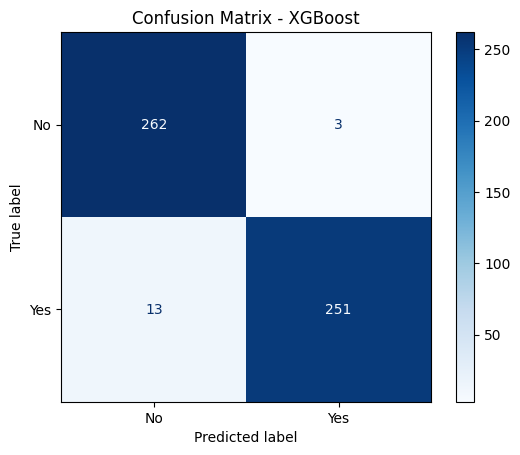

In [120]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred = best_xgb.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix - XGBoost")
plt.show()

In [121]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from trained model
importance = best_xgb.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

# Sort and select top 10
top10 = feature_importance_df.sort_values(by="Importance", ascending=False).head(10)

print(top10)

                                       Feature  Importance
130                  ph_disclose_interview_num    0.107326
115                         mh_career_harm_num    0.069456
49                  state_live_simple_Michigan    0.034845
119                         gender_simple_Male    0.027910
87           mh_disclose_employer_negative_num    0.023435
129               mh_productivity_affected_num    0.023212
42             country_live_simple_Netherlands    0.021814
69                  state_work_simple_Michigan    0.020838
8                               company_size_3    0.020501
85   work_position_simple_Supervisor/Team Lead    0.020062


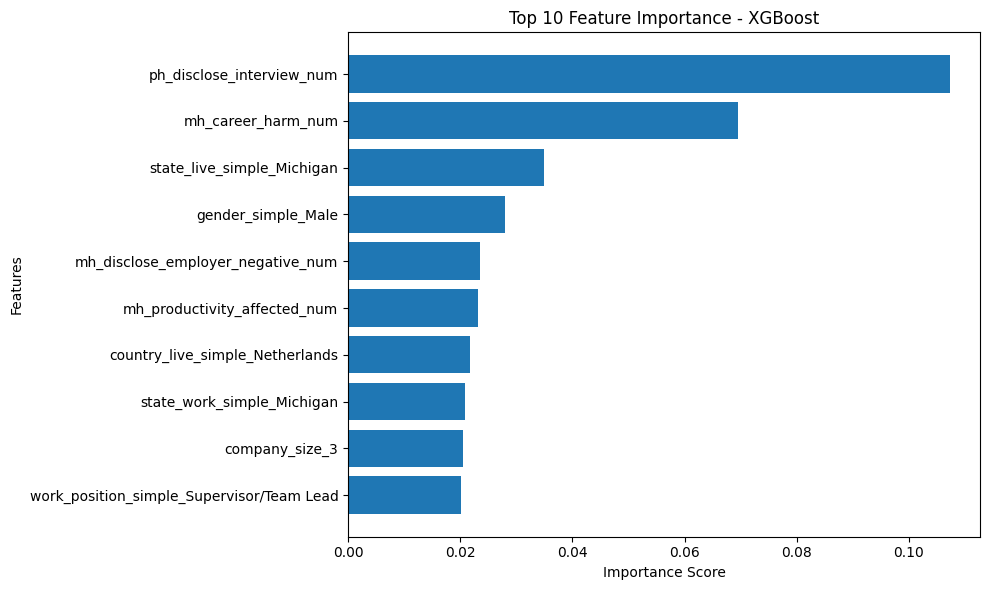

In [122]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = best_xgb.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

# Top 10 features
top10 = feature_importance_df.sort_values(by="Importance", ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1])

plt.title("Top 10 Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

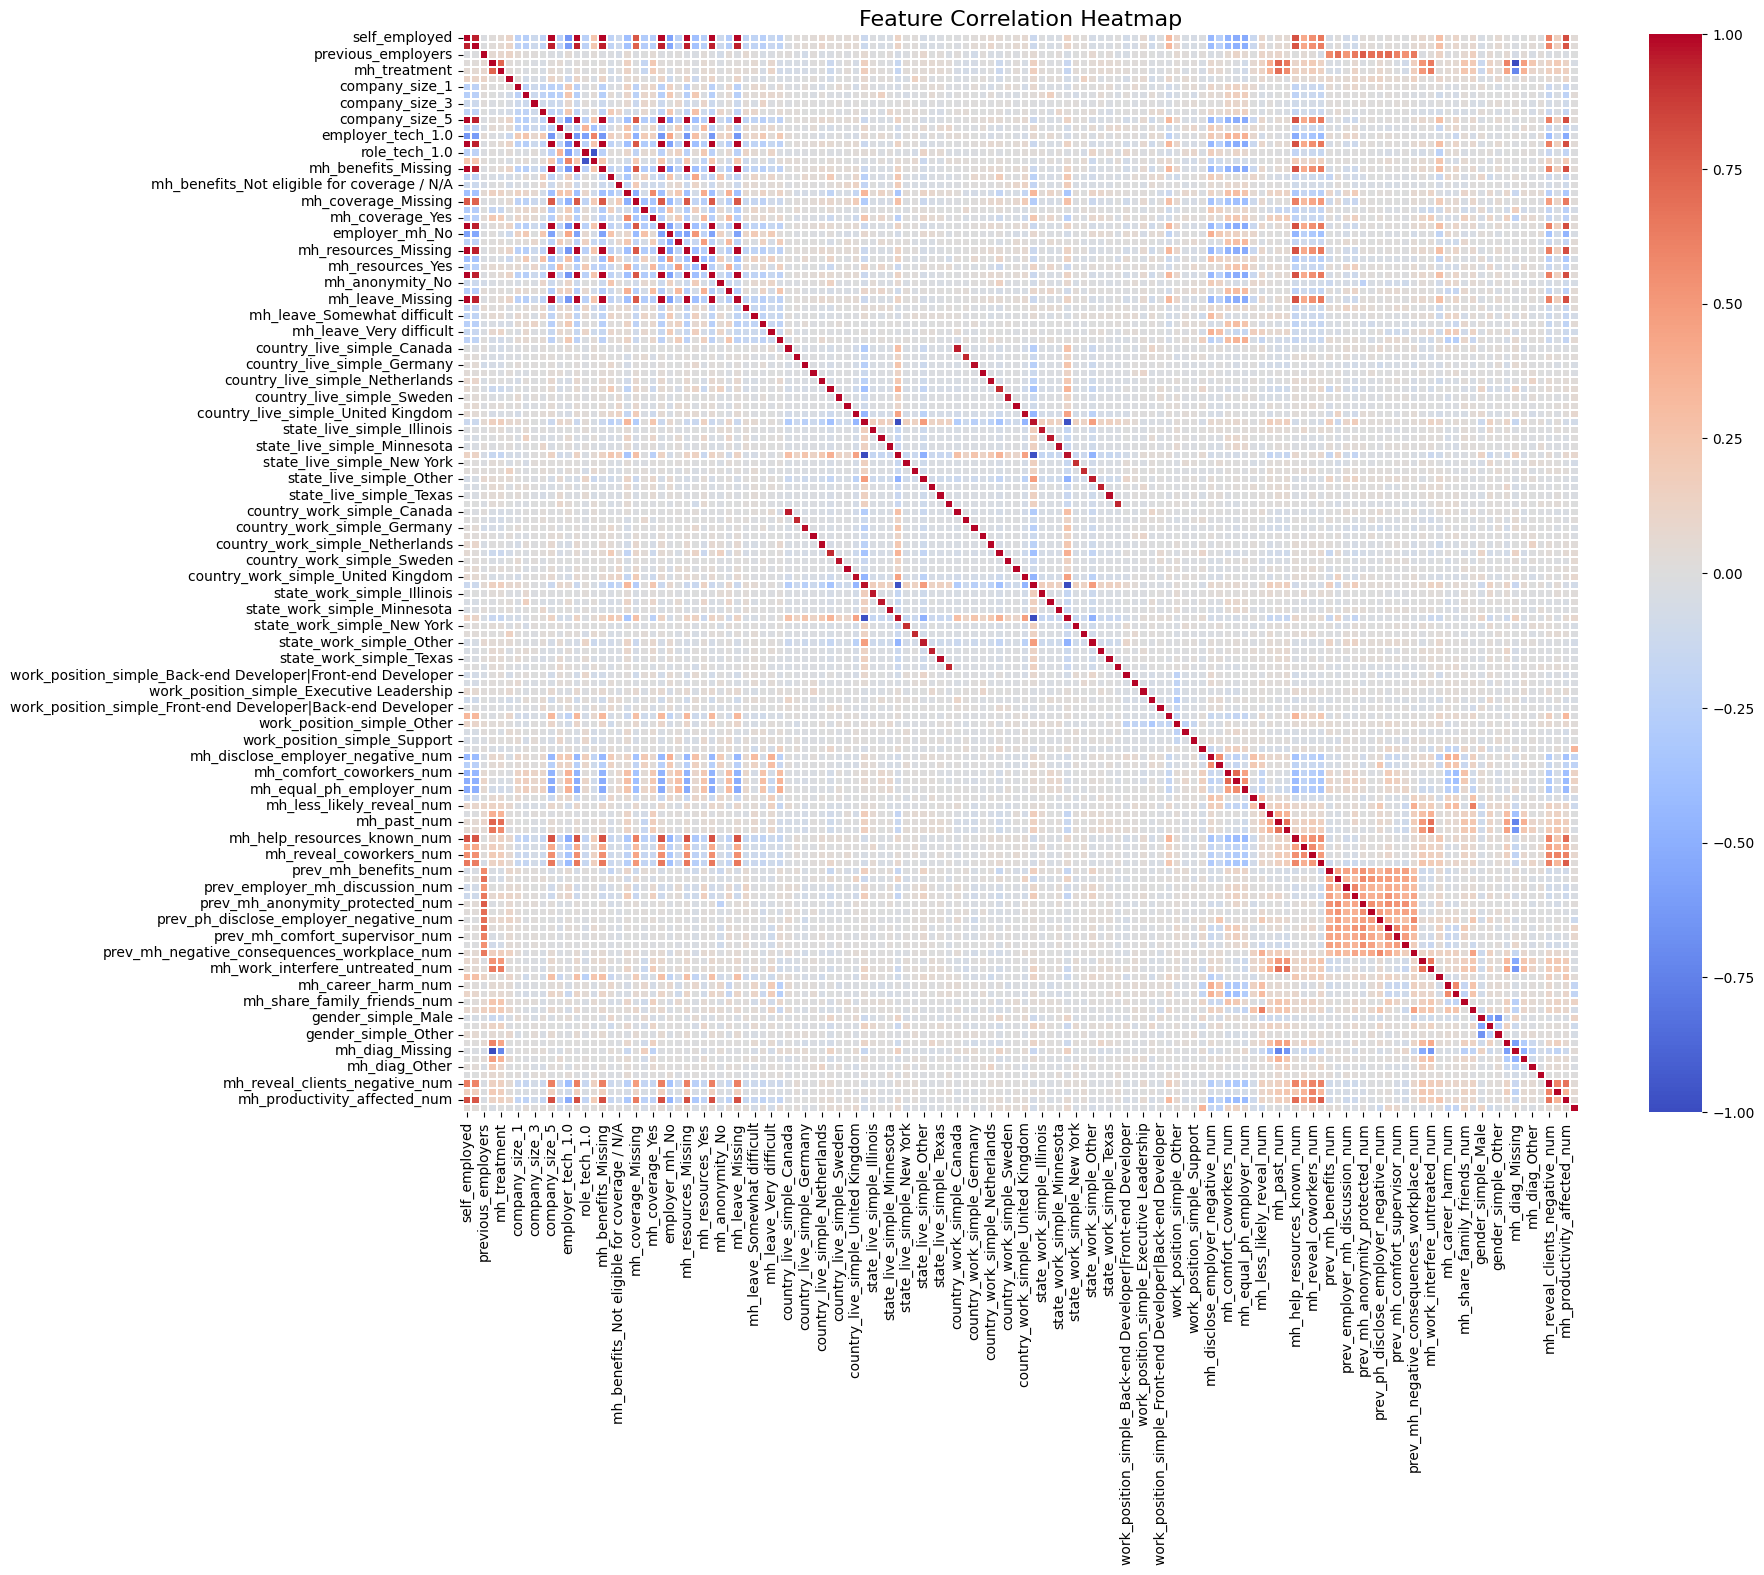

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = df_model.corr()

# Plot heatmap
plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2,
    cbar=True
)

plt.title("Feature Correlation Heatmap", fontsize=16)
plt.show()

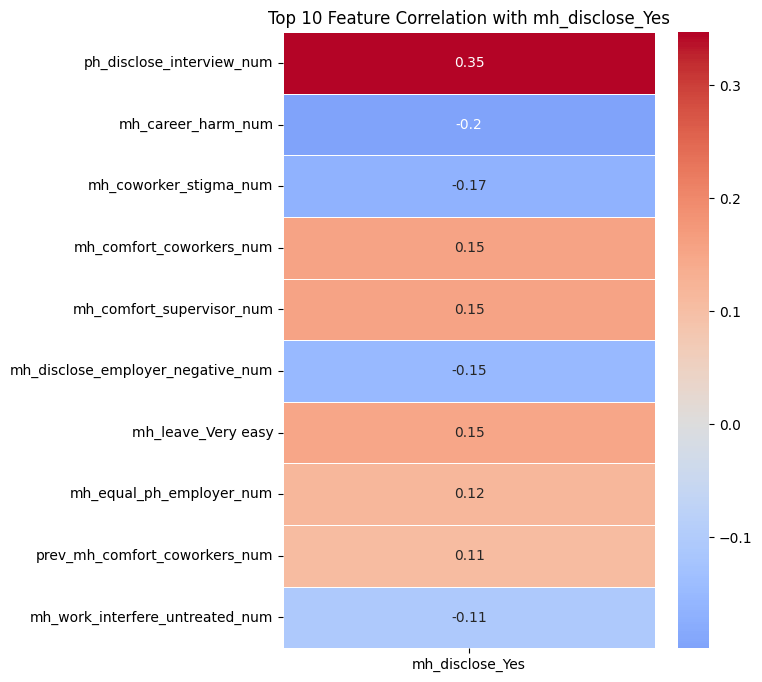

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = df_model.corr()

# Get correlations with target
target_corr = corr_matrix[["mh_disclose_Yes"]].drop("mh_disclose_Yes")

# Select top 10 most correlated features (absolute value)
top10 = target_corr.reindex(
    target_corr["mh_disclose_Yes"].abs().sort_values(ascending=False).head(10).index
)

# Plot heatmap
plt.figure(figsize=(6, 8))

sns.heatmap(
    top10,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Top 10 Feature Correlation with mh_disclose_Yes")
plt.show()

In [125]:
##The model predicts whether an individual will disclose a mental health condition at work (mh_disclose_Yes). Performance is very strong, with accuracy of 0.9698, precision of 0.9882, recall of 0.9508, F1 score of 0.9691, and ROC AUC of 0.9947. The high recall indicates the model correctly identifies most individuals who are likely to disclose mental health conditions, which is particularly important for minimizing missed positive cases. The very high precision demonstrates that false positives are rare, ensuring reliable identification of true disclosures. Overall, the model shows excellent and well-balanced predictive performance with outstanding discriminative ability.##

In [126]:
##The performance of four machine learning models—Logistic Regression, Decision Tree, Random Forest, and XGBoost—was evaluated for predicting whether an individual will disclose a mental health condition at work (mh_disclose_Yes). Among all models, XGBoost achieved the best overall performance, with the highest accuracy (0.9698), recall (0.9508), and F1 score (0.9691), while maintaining an excellent ROC AUC of 0.9947. Random Forest also performed strongly, showing very similar ROC AUC (0.9948) and slightly lower recall (0.9470). Logistic Regression demonstrated stable but lower predictive power across all metrics, while Decision Tree performed the weakest overall. Since recall is the most important metric for this analysis—due to the need to correctly identify individuals likely to disclose mental health conditions—XGBoost is selected as the optimal model. It provides the best balance between sensitivity and overall predictive performance, making it the most reliable model for this classification task.##